# TAP Ticket Analysis


## Contents

1. **Data Quality Audit**
2. **Data Cleaning**
3. **Analysis**
4. **Appendix**

### Analysis sections

| Theme | Sections |
|---|---|
| **Volume & trends** | month-over-month volume + the release inflection · component severity shift, pre vs post |
| **Resolution speed** | resolution by priority/component |
| **Quality & reopens** | reopen rates · label severity vs fragility |
| **Backlog** | open-ticket snapshot + aging · net backlog growth (created > resolved every month) |
| **People & customers** | assignee load · customer concentration check |
| **Summary** | recurring issues · most-requested features · pain score · new-since-release |
| **Conclusion** | synthesis & recommendation |

---

In [3]:
import pandas as pd
import numpy as np

df = pd.read_excel(
    "data/TAP_Desk_Analyst_Project.xlsx",
    sheet_name="Tickets"
)

df.head(20)

,Issue Key,Issue Type,Summary,Status,Priority,Component,Reporter,Assignee,Customer,Created,Resolved,Reopen Count,Labels,Comment Count
0,TD-1,Reported Issue,Refund not processed within 7 days,Closed,High,Payments,j.smith@acme.com,Gita Patel,Cyberdyne Systems,2025-01-01 15:18:25,2025-01-02 21:29:03.272,0,NaN,3
1,TD-2,Feedback,Allow guest checkout,Closed,Low,Checkout,p.wilson@umbrella.com,Ben Ortiz,Globex Industries,2025-01-03 07:15:57,2025-01-09 05:48:25.278,0,config,1
2,TD-3,Reported Issue,3DS challenge loops infinitely,Resolved,Medium,Payments,s.johnson@wayne.com,Alice Chen,Acme Corp,2025-01-03 11:12:47,2025-01-05 20:52:55.088,0,NaN,2
3,TD-4,Feedback,Slack-only mode,Resolved,Low,Notifications,v.martinez@dunder.com,Gita Patel,Cyberdyne Systems,2025-01-03 11:31:46,2025-01-11 02:05:22.212,0,api,1
4,TD-5,Feedback,Suggest related products,Closed,Low,Search,m.davis@initech.com,Alice Chen,Stark Enterprises,2025-01-07 17:16:09,2025-01-12 13:17:17.462,0,NaN,1
5,TD-6,Reported Issue,Tax calculation off for MA,Resolved,Medium,Checkout,s.johnson@wayne.com,Elena Ruiz,Dunder Mifflin,2025-01-08 13:18:02,2025-01-12 01:39:46.299,0,performance,5
6,TD-7,Reported Issue,Payment fails with 'gateway timeout',Resolved,High,Payments,s.johnson@wayne.com,Elena Ruiz,Globex Industries,2025-01-09 09:31:13,2025-01-10 03:53:32.730,2,"regression, ux",5
7,TD-8,Subtask,Discount code not applying at checkout,Closed,Low,Checkout,j.smith@acme.com,Ben Ortiz,Cyberdyne Systems,2025-01-09 09:52:01,2025-01-14 09:03:21.786,0,NaN,1
8,TD-9,Feedback,Suggest related products,Closed,Low,Search,t.lee@hooli.com,Ben Ortiz,Dunder Mifflin,2025-01-09 11:57:38,2025-01-14 16:39:29.573,0,NaN,6
9,TD-10,Subtask,Cannot update billing address,Resolved,Low,Account,s.johnson@wayne.com,Alice Chen,Dunder Mifflin,2025-01-14 13:03:17,2025-01-17 08:03:03.193,0,NaN,7


# Data Exploration

In [4]:
# Re-read the untouched export
raw = pd.read_excel("data/TAP_Desk_Analyst_Project.xlsx", sheet_name="Tickets")

print("Shape:", raw.shape)
print("\nNulls per column:")
display(raw.isna().sum())
print("\nDistinct values per column:")
display(raw.nunique())

Shape: (1000, 14)

Nulls per column:


Issue Key          0
Issue Type         0
Summary            0
Status             0
Priority           0
Component          0
Reporter           0
Assignee          25
Customer           0
Created            0
Resolved         134
Reopen Count       0
Labels           398
Comment Count      0
dtype: int64


Distinct values per column:


Issue Key        1000
Issue Type          3
Summary            77
Status              6
Priority            4
Component          11
Reporter           12
Assignee            8
Customer           10
Created          1000
Resolved          865
Reopen Count        4
Labels             88
Comment Count       9
dtype: int64

## Issue Discovery

- **Whitespace:** any cell where `value != value.strip()` has hidden leading/trailing spaces (this is how `'Search '` and `'payments '` were found)
- **Case/space collisions:** normalize each value (`strip().casefold()`) and check whether one normalized key maps back to *more than one* raw spelling (`checkout` vs `Checkout`)
- **Redundant categories:** dump the value list of every low-cardinality column and scan for synonyms (6 statuses → Closed/Done/Resolved are identical)
- **Hidden multi-values:** check whether a column's cells contain a delimiter like `,` (this flagged `Labels`)
- **Impossible dates:** a duration can never be negative, so a negative `min` in the resolution-time summary exposes the bad rows
- **Missing data:** the `isna().sum()` in the overview cell above is the blind check for nulls


In [5]:
non_text = raw.select_dtypes(include=["number", "datetime", "datetimetz", "timedelta", "bool"]).columns
text_cols = [c for c in raw.columns if c not in non_text]

print("(a) Whitespace, cells where value != value.strip():")
hit = False
for col in text_cols:
    sv = raw[col].dropna().astype(str)
    bad = sorted(sv[sv != sv.str.strip()].unique())
    if bad:
        hit = True
        print(f"{col}: {[repr(b) for b in bad]}")
if not hit:
    print("none")

print("\n(b) Case/space collisions, one normalized key maps to several raw spellings:")
hit = False
for col in text_cols:
    sv = raw[col].dropna().astype(str)
    norm = sv.str.strip().str.casefold()
    for key, ndistinct in sv.groupby(norm).nunique().items():
        if ndistinct > 1:
            hit = True
            print(f"{col}: {sorted(sv[norm == key].unique())}")
if not hit:
    print("none")

print("\n(c) Low-cardinality categoricals (<=12 distinct), eyeball for synonyms/redundancy:")
for col in text_cols:
    if raw[col].nunique() <= 12:
        print(f"{col} ({raw[col].nunique()}): {sorted(raw[col].dropna().unique())}")

print("\n(d) Hidden multi-values, columns whose cells contain a ',' delimiter:")
for col in text_cols:
    sv = raw[col].dropna().astype(str)
    frac = sv.str.contains(",").mean()
    if frac > 0:
        print(f"{col}: {frac:.0%} of non-null cells contain ',' (multi-valued)")

(a) Whitespace, cells where value != value.strip():
Component: ["'Search '", "'payments '"]

(b) Case/space collisions, one normalized key maps to several raw spellings:
Component: ['Checkout', 'checkout']
Component: ['Payments', 'payments ']
Component: ['Search', 'Search ']

(c) Low-cardinality categoricals (<=12 distinct), eyeball for synonyms/redundancy:
Issue Type (3): ['Feedback', 'Reported Issue', 'Subtask']
Status (6): ['Closed', 'Done', 'In Progress', 'In Review', 'Open', 'Resolved']
Priority (4): ['Critical', 'High', 'Low', 'Medium']
Component (11): ['Account', 'Admin', 'Checkout', 'Mobile', 'Notifications', 'Payments', 'Reports', 'Search', 'Search ', 'checkout', 'payments ']
Reporter (12): ['j.smith@acme.com', 'k.brown@globex.com', 'm.davis@initech.com', 'p.wilson@umbrella.com', 'r.taylor@stark.com', 's.johnson@wayne.com', 't.lee@hooli.com', 'u.garcia@pied-piper.com', 'v.martinez@dunder.com', 'w.anderson@cyberdyne.com', 'x.thomas@oscorp.com', 'y.harris@lexcorp.com']
Assignee 

In [6]:
# Date columns: enforce logical constraints (a duration can't be negative)
dts = raw.copy()
dts["Created"]  = pd.to_datetime(dts["Created"], errors="coerce")
dts["Resolved"] = pd.to_datetime(dts["Resolved"], errors="coerce")
dur_hours = (dts["Resolved"] - dts["Created"]).dt.total_seconds() / 3600

print("Unparseable dates (became NaT):  Created =", int(dts["Created"].isna().sum()),
      "| Resolved =", int(dts["Resolved"].isna().sum()))
print("\nResolution-hours summary, a NEGATIVE min reveals impossible records:")
print(dur_hours.describe())
print("\nRows violating 'Resolved >= Created':", int((dur_hours < 0).sum()))

Unparseable dates (became NaT):  Created = 0 | Resolved = 134

Resolution-hours summary, a NEGATIVE min reveals impossible records:
count     866.000000
mean      119.852070
std       154.084340
min       -52.101667
25%        31.156339
50%        69.539851
75%       146.423310
max      1710.255915
dtype: float64

Rows violating 'Resolved >= Created': 4


In [7]:
# The 4 rows behind "Rows violating 'Resolved >= Created'" above
v = raw.copy()
v["Created"]  = pd.to_datetime(v["Created"], errors="coerce")
v["Resolved"] = pd.to_datetime(v["Resolved"], errors="coerce")
v["resolution_hours"] = ((v["Resolved"] - v["Created"]).dt.total_seconds() / 3600).round(2)
display(v.loc[v["resolution_hours"] < 0,
            ["Issue Key", "Issue Type", "Status", "Priority", "Component",
             "Created", "Resolved", "resolution_hours"]])

,Issue Key,Issue Type,Status,Priority,Component,Created,Resolved,resolution_hours
470,TD-471,Reported Issue,Closed,Medium,Payments,2025-11-17 08:42:51,2025-11-16 21:42:51,-11.0
502,TD-503,Feedback,Resolved,Low,Search,2025-11-25 08:42:04,2025-11-25 05:42:04,-3.0
914,TD-915,Reported Issue,Resolved,Critical,Search,2026-04-27 13:38:52,2026-04-27 01:38:52,-12.0
998,TD-999,Reported Issue,In Review,Medium,Account,2026-05-31 09:06:06,2026-05-29 05:00:00,-52.1


In [8]:
print("Component value counts (raw):")
display(raw["Component"].value_counts())

canon = raw["Component"].str.strip().str.title()
variants = sorted(raw["Component"][canon != raw["Component"]].unique(), key=repr)
print("\nLabels that are only case/whitespace variants of a real component:", [repr(v) for v in variants])
print("Distinct labels:", raw["Component"].nunique(), "-> after strip + title-case:", canon.nunique())

Component value counts (raw):


Component
Checkout         246
Search           178
Payments         175
Account          127
Reports           91
Mobile            62
Notifications     57
Admin             34
checkout          17
Search             8
payments           5
Name: count, dtype: int64


Labels that are only case/whitespace variants of a real component: ["'Search '", "'checkout'", "'payments '"]
Distinct labels: 11 -> after strip + title-case: 8


In [9]:
# Issue: Status has 6 values
# Are Closed/Done/Resolved actually different?
print("Status value counts (6 distinct):")
display(raw["Status"].value_counts())

s = raw.copy()
s["Created"]  = pd.to_datetime(s["Created"], errors="coerce")
s["Resolved"] = pd.to_datetime(s["Resolved"], errors="coerce")
s["res_days"] = (s["Resolved"] - s["Created"]).dt.total_seconds() / 86400
s = s[s["res_days"].isna() | (s["res_days"] >= 0)]   # ignore the few negative-duration rows here

print("\nBehaviour by status, Closed/Done/Resolved should look identical if they mean the same thing:")
display(s.groupby("Status").agg(
    n=("Issue Key", "size"),
    pct_with_resolved=("Resolved", lambda x: round(x.notna().mean(), 2)),
    median_days=("res_days", "median"),
    reopen_mean=("Reopen Count", "mean"),
    comment_mean=("Comment Count", "mean"),
).round(2))

Status value counts (6 distinct):


Status
Done           301
Closed         285
Resolved       279
In Progress     48
Open            48
In Review       39
Name: count, dtype: int64


Behaviour by status, Closed/Done/Resolved should look identical if they mean the same thing:


,n,pct_with_resolved,median_days,reopen_mean,comment_mean
Status,,,,,
Closed,284,1.0,2.68,0.14,2.03
Done,301,1.0,3.22,0.14,2.10
In Progress,48,0.0,NaN,0.21,2.35
In Review,38,0.0,NaN,0.26,2.26
Open,48,0.0,NaN,0.23,2.35
Resolved,277,1.0,2.87,0.15,2.25


In [10]:
# Does any feature predict which terminal label (Closed/Done/Resolved) a finished ticket gets?
done = raw[raw["Status"].isin(["Closed", "Done", "Resolved"])].copy()
done["Created"] = pd.to_datetime(done["Created"], errors="coerce")
print("Finished tickets:", len(done), "->", done["Status"].value_counts().to_dict())

for col in ["Reopen Count", "Assignee", "Issue Type", "Priority"]:
    print(f"\n% within each terminal Status -- by {col}:")
    display((pd.crosstab(done["Status"], done[col], normalize="index") * 100).round(1))

print("\nCounts by quarter created -- do all three coexist over time (vs a rename)?")
display(pd.crosstab(done["Created"].dt.to_period("Q"), done["Status"]))
# No feature predicts the label
# Reopen (~90% never-reopened in each), assignee, issue type, priority are all flat across Closed/Done/Resolved + all three appear in every quarter
# The label is uncorrelated with everything measurable -> consistent with three interchangeable names for "finished".

Finished tickets: 865 -> {'Done': 301, 'Closed': 285, 'Resolved': 279}

% within each terminal Status -- by Reopen Count:


Reopen Count,0,1,2,3
Status,,,,
Closed,89.8,7.0,2.8,0.4
Done,90.0,6.0,3.7,0.3
Resolved,89.2,7.9,1.8,1.1



% within each terminal Status -- by Assignee:


Assignee,Alice Chen,Ben Ortiz,Carla Singh,Devon Park,Elena Ruiz,Felix Wong,Gita Patel,Henry Liu
Status,,,,,,,,
Closed,25.4,12.5,5.4,12.9,12.5,10.7,12.1,8.6
Done,22.3,10.3,10.0,10.0,11.3,11.0,11.7,13.4
Resolved,25.2,11.5,12.6,8.9,11.9,11.9,9.6,8.5



% within each terminal Status -- by Issue Type:


Issue Type,Feedback,Reported Issue,Subtask
Status,,,
Closed,28.4,60.4,11.2
Done,30.2,58.1,11.6
Resolved,31.5,62.7,5.7



% within each terminal Status -- by Priority:


Priority,Critical,High,Low,Medium
Status,,,,
Closed,4.2,12.6,35.4,47.7
Done,3.0,16.9,40.2,39.9
Resolved,4.3,11.5,38.7,45.5



Counts by quarter created -- do all three coexist over time (vs a rename)?


Status,Closed,Done,Resolved
Created,,,
2025Q1,24,27,28
2025Q2,45,28,46
2025Q3,36,27,29
2025Q4,71,82,70
2026Q1,67,91,71
2026Q2,42,46,35


- No available feature predicts the terminal label
- Reopen distributions are ~identical (≈90% never-reopened in each), every assignee splits across all three in the same proportions, Issue Type / Priority are proportional, and all three labels appear in every quarter (so it isn't a workflow rename over time either)
- Because the choice is uncorrelated with everything -> `Closed` / `Done` / `Resolved` are three interchangeable names for one "finished" state, which is why we merges them into `Resolved`

In [11]:
# Issues: date logic (contradictions, negative durations, missing Resolved)
d = raw.copy()
d["Created"]  = pd.to_datetime(d["Created"], errors="coerce")
d["Resolved"] = pd.to_datetime(d["Resolved"], errors="coerce")
d["res_hours"] = (d["Resolved"] - d["Created"]).dt.total_seconds() / 3600
DONE = {"Closed", "Done", "Resolved"}

print("1) Open-status tickets that wrongly carry a Resolved date:")
display(d.loc[~d["Status"].isin(DONE) & d["Resolved"].notna(),
            ["Issue Key", "Status", "Created", "Resolved"]])

print("\n2) Tickets 'resolved' BEFORE they were created (negative duration):")
neg = d.loc[d["res_hours"] < 0, ["Issue Key", "Status", "Created", "Resolved", "res_hours"]].copy()
neg["res_hours"] = neg["res_hours"].round(2) # round only the numeric column
display(neg)
print("(TD-999 appears in both 1 and 2; we handle it as the contradiction -> Resolved nulled,")
print("leaving 3 genuine negative-duration rows to flag.)")

print("\n3) Is missing Resolved == open tickets? (cross-tab status-group vs Resolved missing)")
grp = d["Status"].isin(DONE).map({True: "done-status", False: "open-status"})
print(pd.crosstab(grp, d["Resolved"].isna().map({True: "Resolved missing", False: "Resolved present"})))

1) Open-status tickets that wrongly carry a Resolved date:


,Issue Key,Status,Created,Resolved
998,TD-999,In Review,2026-05-31 09:06:06,2026-05-29 05:00:00



2) Tickets 'resolved' BEFORE they were created (negative duration):


,Issue Key,Status,Created,Resolved,res_hours
470,TD-471,Closed,2025-11-17 08:42:51,2025-11-16 21:42:51,-11.0
502,TD-503,Resolved,2025-11-25 08:42:04,2025-11-25 05:42:04,-3.0
914,TD-915,Resolved,2026-04-27 13:38:52,2026-04-27 01:38:52,-12.0
998,TD-999,In Review,2026-05-31 09:06:06,2026-05-29 05:00:00,-52.1


(TD-999 appears in both 1 and 2; we handle it as the contradiction -> Resolved nulled,
leaving 3 genuine negative-duration rows to flag.)

3) Is missing Resolved == open tickets? (cross-tab status-group vs Resolved missing)
Resolved     Resolved missing  Resolved present
Status                                         
done-status                 0               865
open-status               134                 1


In [12]:
# Issues: missing Resolved / Assignee / Labels
print("Missing Resolved:", int(raw["Resolved"].isna().sum()),
      "-> these are the open tickets (alignment proven in the dates cell above)")
print("Missing Assignee:", int(raw["Assignee"].isna().sum()),
      f"({raw['Assignee'].isna().mean():.0%}) -> unassigned tickets")
print("Missing Labels  :", int(raw["Labels"].isna().sum()),
      f"({raw['Labels'].isna().mean():.0%}) -> tickets with no tags")

print("\nLabels is multi-valued (comma-separated), examples:")
multi = raw["Labels"].dropna()
display(multi[multi.str.contains(",")].head(5))

Missing Resolved: 134 -> these are the open tickets (alignment proven in the dates cell above)
Missing Assignee: 25 (2%) -> unassigned tickets
Missing Labels  : 398 (40%) -> tickets with no tags

Labels is multi-valued (comma-separated), examples:


6                regression, ux
22        ui-bug, p1-escalation
39                edge-case, ux
40    performance, data-quality
47    performance, data-quality
Name: Labels, dtype: str

In [13]:
# Is the reporter's email domain tied to the Customer?
raw_dom = raw.assign(domain=raw["Reporter"].str.split("@").str[1])
print("\nDistinct reporter email-domains seen per Customer (12 = fully independent of Customer):")
display(raw_dom.groupby("Customer")["domain"].nunique())


Distinct reporter email-domains seen per Customer (12 = fully independent of Customer):


Customer
Acme Corp            12
Cyberdyne Systems    12
Dunder Mifflin       12
Globex Industries    12
Hooli Inc            12
Initech              12
Pied Piper           12
Stark Enterprises    12
Umbrella Holdings    12
Wayne Industries     12
Name: domain, dtype: int64

# Data Cleaning


| Issue (proven above) | Handling |
|-------|----------|
| **Component** casing/whitespace dupes (`checkout`, `payments `, `Search `) | strip + title-case → 11 labels collapse to 8 real components |
| **Status** has 6 values | Both trios are *statistically* indistinguishable on what we can measure, so this is a **semantic + cost** call, **not** a claim that one trio is "proven" identical and the other isn't. **Merge Closed/Done/Resolved → `Resolved`:** they are synonyms for one terminal state (assumption); the data is consistent with that (all 100% resolved; matching timing/reopen/comments), they can be tested on their *defining* outcome, resolution time, and it matches; and merging removes a meaningless 3-way split of "finished." **Keep Open/In Progress/In Review:** these are conventionally *distinct* workflow stages (assumption) whose real differentiator (pipeline position / time-in-stage) is **unmeasurable here** (all 0% resolved, no status-history), so "no difference found" is weaker than for the done-trio, and merging is irreversible while keeping them costs nothing. The binary Resolved/Open cut is **derived on the fly** as `status_clean == "Resolved"`. *(Export overwrites raw `Status` with the merged values.)* |
| **TD-999** is `In Review` but had a Resolved date (before its Created time) | Resolved date nulled, treated as unresolved |
| **3 corrupt durations** (resolved before created; the 4th such row is TD-999) | computed `resolution_hours`/`days` set to `NaN` so timing math ignores them; **raw dates kept** so the glitch stays visible; tracked by a code-only variable `invalid_resolution` (not exported). Note: "not complete" tickets are **not** flagged, a blank `Resolved`/`resolution_hours` already signals incompleteness, distinct from corrupt timing. |
| **134 missing Resolved** | legitimate, these are the open tickets; left null (this *is* the "not complete" signal) |
| **25 missing Assignee** | filled `"Unassigned"`. Note: unassigned tickets are mostly *resolved* (24/25 are Done/Resolved/Closed), not open |
| **398 missing Labels** | blank = no labels → empty `label_list` |


Other checks that came back clean: no duplicate Issue Keys, no duplicate rows, Reopen (0-3) and Comment (0-8) counts all valid, all Reporter emails well-formed, all Created/Resolved dates in range, all keys match `TD-<n>`, no blank summaries.

Assumptions: timestamps are naive local time; the reporter-email domain is independent of `Customer` (every customer shows all 12 domains), so we never infer customer from the reporter. We do **not** assign operational meaning to the status labels beyond what the data shows (e.g. we do not claim `Open` = untouched, in fact 47/48 Open tickets have an assignee).

In [14]:
# ===== Consolidated data cleaning =====
# Single source of truth: every downstream cell inherits these cleaned columns.
df_raw = df.copy()   # untouched copy for auditing

# 1. Component: strip whitespace + canonical casing.
#    Collapses 'checkout', 'payments', 'Search ' back into Checkout/Payments/Search.
df["Component"] = df["Component"].str.strip().str.title()

# Strip stray whitespace on the other categoricals too.
for col in ["Issue Type", "Status", "Priority", "Customer"]:
    df[col] = df[col].str.strip()

# 2. Status normalization -> a single cleaned column, `status_clean`.
#    Both trios are statistically indistinguishable on the features we can measure, so this is a
#    SEMANTIC + COST decision -- NOT "one trio is proven equivalent and the other isn't":
#    - Closed/Done/Resolved are SYNONYMS for one terminal state (assumption); the data is consistent (all 100%
#      resolved, matching timing/reopen/comments) and merging removes a meaningless 3-way split
#      -> collapse to "Resolved".
#    - Open/In Progress/In Review are conventionally DISTINCT stages (assumption); their real differentiator
#      (pipeline position) is unmeasurable here (no status-history) and merging is irreversible,
#      so we keep them.
#    - The binary Resolved/Open cut is simply (status_clean == "Resolved"), derived where needed.
DONE_STATES = {"Closed", "Done", "Resolved"}
df["status_clean"] = df["Status"].where(~df["Status"].isin(DONE_STATES), "Resolved")

# 3. Datetimes.
df["Created"] = pd.to_datetime(df["Created"], errors="coerce")
df["Resolved"] = pd.to_datetime(df["Resolved"], errors="coerce")

# 4. Fix contradiction: an unresolved ticket should not carry a Resolved date.
#    (TD-999 is 'In Review' yet had a Resolved timestamp -- and before its Created time.)
contradiction = (df["status_clean"] != "Resolved") & df["Resolved"].notna()
df.loc[contradiction, "Resolved"] = pd.NaT

# 5. Resolution time.
#    Open / not-yet-resolved tickets have no Resolved date, so resolution is NaN -- that blank
#    IS the "not complete" signal; we do NOT flag it as invalid.
df["resolution_hours"] = (df["Resolved"] - df["Created"]).dt.total_seconds() / 3600
df["resolution_days"] = df["resolution_hours"] / 24

#    Separately, a few RESOLVED tickets have a Resolved date BEFORE Created (data error -> a
#    negative duration). That's genuinely corrupt timing, not "incomplete". Null the computed
#    duration so every timing calc ignores them, but keep their raw dates visible.
#    `invalid_resolution` is a CODE-ONLY mask (not a stored/exported column).
invalid_resolution = df["resolution_hours"] < 0
df.loc[invalid_resolution, ["resolution_hours", "resolution_days"]] = np.nan

# 6. Assignee: 25 blanks are unassigned tickets, not errors.
df["Assignee"] = df["Assignee"].fillna("Unassigned")

# 7. Issue Type flag: Subtasks treated as normal tickets (no parent-link to prove hierarchy);
#    flag kept only for optional filtering.
df["is_subtask"] = df["Issue Type"].eq("Subtask")

# 8. Labels -> normalized list (blank = empty list).
df["label_list"] = (
    df["Labels"].fillna("").str.split(",")
    .apply(lambda lst: [t.strip().lower() for t in lst if t.strip()])
)

# 9. Time features + release flag (major release shipped 2025-10-01)
RELEASE_DATE = pd.Timestamp("2025-10-01")
df["created_month"] = df["Created"].dt.to_period("M")
df["created_dow"] = df["Created"].dt.day_name()
df["post_release"] = df["Created"] >= RELEASE_DATE

# 10. Normalized summary: collapse variable tokens (order #s, state codes) so templated
#     families (e.g. "Duplicate charge for order #N", "Tax calculation off for {STATE}")
#     aggregate instead of scattering across unique strings. Used by the Summary cells.
df["summary_norm"] = (df["Summary"]
    .str.replace(r"#\d+", "#N", regex=True)
    .str.replace(r"\bfor [A-Z]{2}\b", "for {STATE}", regex=True))

df.head()

,Issue Key,Issue Type,Summary,Status,Priority,Component,Reporter,Assignee,Customer,Created,...,Comment Count,status_clean,resolution_hours,resolution_days,is_subtask,label_list,created_month,created_dow,post_release,summary_norm
0,TD-1,Reported Issue,Refund not processed within 7 days,Closed,High,Payments,j.smith@acme.com,Gita Patel,Cyberdyne Systems,2025-01-01 15:18:25,...,3,Resolved,30.177298,1.257387,False,[],2025-01,Wednesday,False,Refund not processed within 7 days
1,TD-2,Feedback,Allow guest checkout,Closed,Low,Checkout,p.wilson@umbrella.com,Ben Ortiz,Globex Industries,2025-01-03 07:15:57,...,1,Resolved,142.541188,5.939216,False,[config],2025-01,Friday,False,Allow guest checkout
2,TD-3,Reported Issue,3DS challenge loops infinitely,Resolved,Medium,Payments,s.johnson@wayne.com,Alice Chen,Acme Corp,2025-01-03 11:12:47,...,2,Resolved,57.668913,2.402871,False,[],2025-01,Friday,False,3DS challenge loops infinitely
3,TD-4,Feedback,Slack-only mode,Resolved,Low,Notifications,v.martinez@dunder.com,Gita Patel,Cyberdyne Systems,2025-01-03 11:31:46,...,1,Resolved,182.560059,7.606669,False,[api],2025-01,Friday,False,Slack-only mode
4,TD-5,Feedback,Suggest related products,Closed,Low,Search,m.davis@initech.com,Alice Chen,Stark Enterprises,2025-01-07 17:16:09,...,1,Resolved,116.019017,4.834126,False,[],2025-01,Tuesday,False,Suggest related products


In [15]:
# before vs after
print("Component values, before:", df_raw["Component"].nunique(),
      "| after:", df["Component"].nunique())
print("  collapsed dupes:", sorted(set(df_raw["Component"].unique()) - set(df["Component"].unique())))
print()
print("Status, raw (6 values) -> status_clean (done-trio merged to 'Resolved', open labels kept):")
display(df["status_clean"].value_counts())
print("Binary cut derived on the fly (status_clean == 'Resolved'):  Resolved =",
      int((df["status_clean"] == "Resolved").sum()), "| Open =", int((df["status_clean"] != "Resolved").sum()))
print()
print("Status contradiction fixed (unresolved ticket carrying a Resolved date):", int(contradiction.sum()))
display(df_raw.loc[contradiction, ["Issue Key", "Status", "Created", "Resolved"]])
print()
print("Corrupt timing nulled (resolved BEFORE created), raw dates kept, tracked by code variable:",
      int(invalid_resolution.sum()))
display(df_raw.loc[invalid_resolution, ["Issue Key", "Status", "Created", "Resolved"]])
print()
print("Assignee blanks filled -> 'Unassigned':", int(df_raw["Assignee"].isna().sum()))
print()
print("Resolution time, usable:", int(df["resolution_hours"].notna().sum()),
      "| not complete (no Resolved date):", int(df["Resolved"].isna().sum()),
      "| corrupt (nulled):", int(invalid_resolution.sum()))
print("Subtasks (flagged, kept as normal tickets):", int(df["is_subtask"].sum()))

Component values, before: 11 | after: 8
  collapsed dupes: ['Search ', 'checkout', 'payments ']

Status, raw (6 values) -> status_clean (done-trio merged to 'Resolved', open labels kept):


status_clean
Resolved       865
In Progress     48
Open            48
In Review       39
Name: count, dtype: int64

Binary cut derived on the fly (status_clean == 'Resolved'):  Resolved = 865 | Open = 135

Status contradiction fixed (unresolved ticket carrying a Resolved date): 1


,Issue Key,Status,Created,Resolved
998,TD-999,In Review,2026-05-31 09:06:06,2026-05-29 05:00:00



Corrupt timing nulled (resolved BEFORE created), raw dates kept, tracked by code variable: 3


,Issue Key,Status,Created,Resolved
470,TD-471,Closed,2025-11-17 08:42:51,2025-11-16 21:42:51
502,TD-503,Resolved,2025-11-25 08:42:04,2025-11-25 05:42:04
914,TD-915,Resolved,2026-04-27 13:38:52,2026-04-27 01:38:52



Assignee blanks filled -> 'Unassigned': 25

Resolution time, usable: 862 | not complete (no Resolved date): 135 | corrupt (nulled): 3
Subtasks (flagged, kept as normal tickets): 95


### Decision for 4 impossible-date rows (TD-471, TD-503, TD-915, TD-999)

All four have a `Resolved` timestamp *before* their `Created` time. The guiding rule is **trust the recorded `Status`, and treat the bad `Resolved` timestamp as the unreliable field**, because the timestamp is the one that's *demonstrably* broken (a resolution can't precede creation), while `Status` is internally consistent with the rest of the data (every one of the other 134 open tickets correctly has no `Resolved` date, so "not-done ⇒ no resolved date" is the established norm)

| Ticket | Raw `Status` | Status vs. date | Handling |
|---|---|---|---|
| TD-471 | Closed | consistent (done and has a date) | keep Resolved; null the negative duration |
| TD-503 | Resolved | consistent | keep Resolved; null duration |
| TD-915 | Resolved | consistent | keep Resolved; null duration |
| TD-999 | In Review | contradiction (open but has a date) | void the spurious date; keep In Review |

For the first three, the status and the presence of a resolved date agree, only the timestamp's value is wrong, so we keep them resolved and simply drop the impossible duration from timing math (raw dates retained for visibility).

TD-999 is genuinely ambiguous, and worth being explicit about. Two defensible readings:
- (a) Trust the status → it's `In Review` (still open) and the `Resolved` date is spurious leftover data
- *(b) Trust the date's existence → it was actually finished and the status just never got updated, so it should be `Resolved`

- Choosing (a) because the date is odd + impossible (-52h), which makes it the least trustworthy field
- "an open ticket carrying a stray resolved date" is a more typical data-entry slip than the reverse

In [16]:
# Component holds only distinct canonical labels (no case/whitespace dupes)
# cleaning should have collapsed the 11 raw spellings to 8
comp = df["Component"]
print("Distinct Component labels after cleaning:", comp.nunique())
print(sorted(comp.unique()))

residual_ws_case = [v for v in comp.unique() if v != v.strip().title()] # any value not already canonical
collisions = comp.groupby(comp.str.strip().str.casefold()).nunique() # one key -> >1 spelling?
print("Residual whitespace/case-variant labels:", residual_ws_case)
print("Normalized keys mapping to >1 spelling :", int((collisions > 1).sum()))

assert comp.nunique() == 8 and not residual_ws_case and (collisions <= 1).all(), \
    "Component still contains duplicate labels!"
# Exactly 8 distinct components (no residual whitespace/case variants)

Distinct Component labels after cleaning: 8
['Account', 'Admin', 'Checkout', 'Mobile', 'Notifications', 'Payments', 'Reports', 'Search']
Residual whitespace/case-variant labels: []
Normalized keys mapping to >1 spelling : 0


In [17]:
# Export cleaned dataset 
from openpyxl.utils import get_column_letter

export = df.copy()

# Status changed in place: Closed/Done/Resolved -> "Resolved"; Open / In Progress / In Review kept
export["Status"] = export["status_clean"]

# Make derived columns spreadsheet-friendly.
export["label_list"] = export["label_list"].apply(lambda lst: ", ".join(lst)) # list -> text
export["created_month"] = export["created_month"].astype(str) # Period -> "YYYY-MM"
export["resolution_hours"] = export["resolution_hours"].round(2)

# Original columns + only the derived columns
cols = [
    "Issue Key", "Issue Type", "Summary", "Status", "Priority", "Component",
    "Reporter", "Assignee", "Customer",
    "Created", "created_month", "post_release",
    "Resolved", "resolution_hours",
    "Reopen Count",
    "Labels", "label_list",
    "Comment Count",
]
export = export[cols]

out_path = "data/TAP_Desk_cleaned.xlsx"
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    export.to_excel(writer, index=False, sheet_name="Tickets")
    ws = writer.sheets["Tickets"]
    DATE_FMT = "yyyy-mm-dd hh:mm:ss"
    for name in ["Created", "Resolved"]:
        letter = get_column_letter(cols.index(name) + 1)
        for row in range(2, len(export) + 2):          # row 1 is the header
            ws[f"{letter}{row}"].number_format = DATE_FMT

print("Wrote", out_path, "->", export.shape[0], "rows x", export.shape[1], "cols")
print("Columns:", list(export.columns))
export.head()

Wrote data/TAP_Desk_cleaned.xlsx -> 1000 rows x 18 cols
Columns: ['Issue Key', 'Issue Type', 'Summary', 'Status', 'Priority', 'Component', 'Reporter', 'Assignee', 'Customer', 'Created', 'created_month', 'post_release', 'Resolved', 'resolution_hours', 'Reopen Count', 'Labels', 'label_list', 'Comment Count']


,Issue Key,Issue Type,Summary,Status,Priority,Component,Reporter,Assignee,Customer,Created,created_month,post_release,Resolved,resolution_hours,Reopen Count,Labels,label_list,Comment Count
0,TD-1,Reported Issue,Refund not processed within 7 days,Resolved,High,Payments,j.smith@acme.com,Gita Patel,Cyberdyne Systems,2025-01-01 15:18:25,2025-01,False,2025-01-02 21:29:03.272,30.18,0,NaN,,3
1,TD-2,Feedback,Allow guest checkout,Resolved,Low,Checkout,p.wilson@umbrella.com,Ben Ortiz,Globex Industries,2025-01-03 07:15:57,2025-01,False,2025-01-09 05:48:25.278,142.54,0,config,config,1
2,TD-3,Reported Issue,3DS challenge loops infinitely,Resolved,Medium,Payments,s.johnson@wayne.com,Alice Chen,Acme Corp,2025-01-03 11:12:47,2025-01,False,2025-01-05 20:52:55.088,57.67,0,NaN,,2
3,TD-4,Feedback,Slack-only mode,Resolved,Low,Notifications,v.martinez@dunder.com,Gita Patel,Cyberdyne Systems,2025-01-03 11:31:46,2025-01,False,2025-01-11 02:05:22.212,182.56,0,api,api,1
4,TD-5,Feedback,Suggest related products,Resolved,Low,Search,m.davis@initech.com,Alice Chen,Stark Enterprises,2025-01-07 17:16:09,2025-01,False,2025-01-12 13:17:17.462,116.02,0,NaN,,1


# Analysis

Convenience frames defined in the setup cell:
- `resolved`: finished tickets (`status_clean == "Resolved"`)
- `timed`: tickets with a usable `resolution_hours` (excludes open tickets and the 3 corrupt-timing rows)
- `pre` / `post`: tickets created before / on-or-after the release

In [18]:
import matplotlib.pyplot as plt

RELEASE = pd.Timestamp("2025-10-01")
resolved = df[df["status_clean"] == "Resolved"].copy() # finished tickets
timed = df[df["resolution_hours"].notna()].copy()# usable resolution time (excl. open + corrupt)
pre, post = df[~df["post_release"]], df[df["post_release"]]
pre_months = pre["Created"].dt.to_period("M").nunique()
post_months = post["Created"].dt.to_period("M").nunique()

print(f"Total tickets: {len(df)}  |  resolved: {len(resolved)}  |  open: {len(df) - len(resolved)}")
print(f"Usable for timing: {len(timed)}")
print(f"Span: {df['Created'].min().date()} -> {df['Created'].max().date()}")
print(f"Pre-release window: {pre_months} months ({len(pre)} tickets)  |  "
      f"Post-release: {post_months} months ({len(post)} tickets)")

Total tickets: 1000  |  resolved: 865  |  open: 135
Usable for timing: 862
Span: 2025-01-01 -> 2026-05-31
Pre-release window: 9 months (332 tickets)  |  Post-release: 8 months (668 tickets)


In [19]:
def resolution_summary(data, group_cols, min_count=5):
    summary = (
        data
        .groupby(group_cols, dropna=False)["resolution_days"]
        .agg(
            count="count",
            median_days="median",
            avg_days="mean",
            max_days="max"
        )
        .reset_index()
    )

    summary = summary[summary["count"] >= min_count]

    return summary.sort_values(
        ["median_days", "count"], 
        ascending=[False, False]
    )

## Volume & trends

- Top components by volume
- Has the mix shifted over time?
- month-over-month trend

Created
2025-01-01    25
2025-02-01    40
2025-03-01    33
2025-04-01    35
2025-05-01    49
2025-06-01    42
2025-07-01    39
2025-08-01    31
2025-09-01    38
2025-10-01    89
2025-11-01    92
2025-12-01    72
2026-01-01    73
2026-02-01    91
2026-03-01    94
2026-04-01    77
2026-05-01    80
dtype: int64

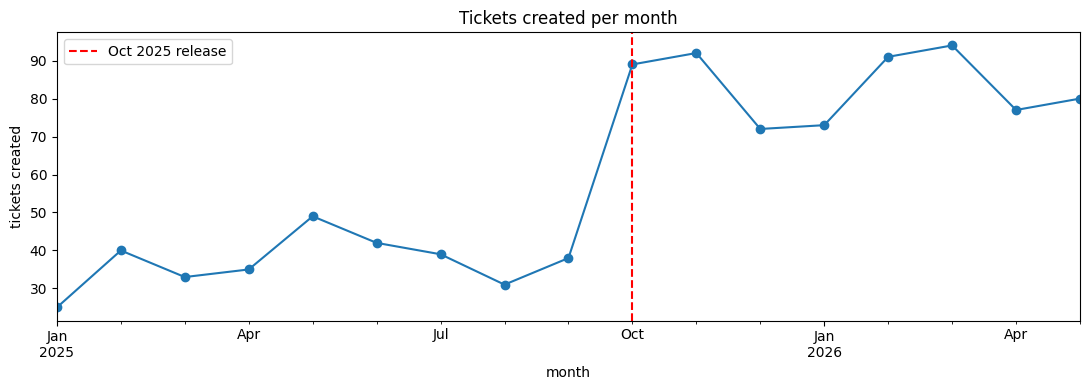

In [20]:
# "Did intake change?"
# Plot counts per month and draw the release line
# Month-over-month created volume
monthly = df.groupby(df["Created"].dt.to_period("M").dt.to_timestamp()).size()
display(monthly)

fig, ax = plt.subplots(figsize=(11, 4))
monthly.plot(marker="o", ax=ax)
ax.axvline(RELEASE, color="red", ls="--", lw=1.5, label="Oct 2025 release")
ax.set_title("Tickets created per month")
ax.set_ylabel("tickets created"); ax.set_xlabel("month"); ax.legend()
plt.tight_layout(); plt.show()

# Sharp step at Oct 2025 (38 -> 89) to a new plateau (~80-94/mo)

In [21]:
# Two windows aren't equal length (9 months pre vs 8 post), so raw totals would mislead
# Convert to tickets-PER-MONTH so they're comparable, and split by Issue Type to see whether the
    # jump is Reported Issues or Feedback 
# Pre vs post-release run-rate (tickets per month), overall and by Issue Type
overall = (len(post)/post_months) / (len(pre)/pre_months) - 1
print(f"Overall run-rate: pre {len(pre)/pre_months:.1f}/mo  ->  post {len(post)/post_months:.1f}/mo  ({overall:+.0%})")
print()
rate = pd.DataFrame({
    "pre_per_mo":  pre.groupby("Issue Type").size() / pre_months,
    "post_per_mo": post.groupby("Issue Type").size() / post_months,
}).round(1)
rate["change"] = ((rate["post_per_mo"] / rate["pre_per_mo"] - 1) * 100).round(0).astype(int).astype(str) + "%"
print("Run-rate by Issue Type:")
display(rate)

# Both rose, but Reported Issues fastest (+132% vs Feedback +106%); overall +126% (37 -> 84/mo)

Overall run-rate: pre 36.9/mo  ->  post 83.5/mo  (+126%)

Run-rate by Issue Type:


,pre_per_mo,post_per_mo,change
Issue Type,,,
Feedback,11.7,24.1,106%
Reported Issue,22.0,51.1,132%
Subtask,3.2,8.2,156%


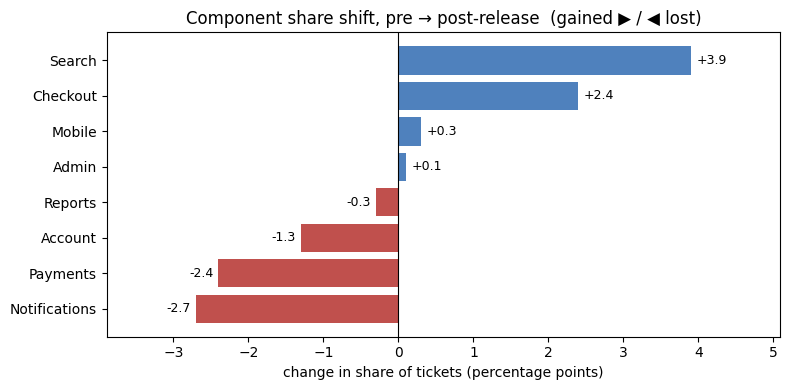

Component mix, pre vs post-release (sorted by biggest gain):


,pre_%,post_%,delta_pts
Component,,,
Search,16.0,19.9,3.9
Checkout,24.7,27.1,2.4
Mobile,6.0,6.3,0.3
Admin,3.3,3.4,0.1
Reports,9.3,9.0,-0.3
Account,13.6,12.3,-1.3
Payments,19.6,17.2,-2.4
Notifications,7.5,4.8,-2.7


In [22]:
# Compare each component's share of tickets pre vs post-release
mix = pd.DataFrame({
    "pre_%": (pre["Component"].value_counts(normalize=True) * 100).round(1),
    "post_%": (post["Component"].value_counts(normalize=True) * 100).round(1),
})
mix["delta_pts"] = (mix["post_%"] - mix["pre_%"]).round(1)

ms = mix.sort_values("delta_pts")
colors = ["#c0504d" if v < 0 else "#4f81bd" for v in ms["delta_pts"]]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(ms.index, ms["delta_pts"], color=colors)
ax.axvline(0, color="black", lw=0.8)
for y, v in enumerate(ms["delta_pts"]):
    ax.text(v + (0.07 if v >= 0 else -0.07), y, f"{v:+.1f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9)
ax.set_title("Component share shift, pre → post-release  (gained ▶ / ◀ lost)")
ax.set_xlabel("change in share of tickets (percentage points)")
ax.margins(x=0.18)
plt.tight_layout(); plt.show()

print("Component mix, pre vs post-release (sorted by biggest gain):")
display(mix.sort_values("delta_pts", ascending=False))
# Search +3.9 pts and Checkout +2.4 pts gained share; Payments / Notifications / Account lost share

- The Oct-1 release is a clear inflection: monthly volume steps from ~38 to ~89 and holds at a new plateau (~80-94/mo)
- Run-rate is +126% overall, with Reported Issues (+132%) outpacing Feedback (+106%), the release created proportionally more Reported Issues than Feedback
- Also tilted toward **Search (+3.9 pts)** and **Checkout (+2.4 pts)**, so post-release attention should weight those areas

## Resolution time

- Which priority/component combinations have the longest resolution times? 
- Did the release change resolution speed?

Uses `timed` (resolved tickets with a valid duration)
Median is the headline stat, resolution time is right-skewed.

In [23]:
# If it's right-skewed, use median, not mean
# Which priority x component combos are slowest?
# Overall resolution-time distribution + the slowest priority x component combos
print("Overall resolution time (days):")
display(timed["resolution_days"].describe().round(2))
print()
print("Slowest priority x component combos (median days, min 5 tickets):")
display(resolution_summary(timed, ["Priority", "Component"], min_count=5).head(12))

# Right-skewed (median 2.9d < mean 5.0d, max 71d); slowest combos are ALL Low priority, led by Low x Payments (9.0d)

Overall resolution time (days):


count    862.00
mean       5.02
std        6.42
min        0.07
25%        1.33
50%        2.95
75%        6.11
max       71.26
Name: resolution_days, dtype: float64


Slowest priority x component combos (median days, min 5 tickets):


,Priority,Component,count,median_days,avg_days,max_days
20,Low,Payments,50,9.045212,11.863554,71.260663
19,Low,Notifications,18,7.272465,10.391519,49.322343
15,Low,Account,49,6.464179,9.613548,48.148897
18,Low,Mobile,24,6.145532,9.140456,29.027735
16,Low,Admin,14,6.093338,9.655678,39.905853
22,Low,Search,65,5.205071,6.993843,27.767166
17,Low,Checkout,87,5.183186,6.858834,33.583837
21,Low,Reports,22,4.030754,6.723475,28.122589
28,Medium,Payments,64,3.778905,5.392260,14.821640
27,Medium,Notifications,21,2.689677,3.403111,12.865953


,count,median,mean
Priority,,,
Critical,32,0.24,0.25
High,119,0.72,1.10
Medium,382,2.39,3.62
Low,329,5.89,8.53


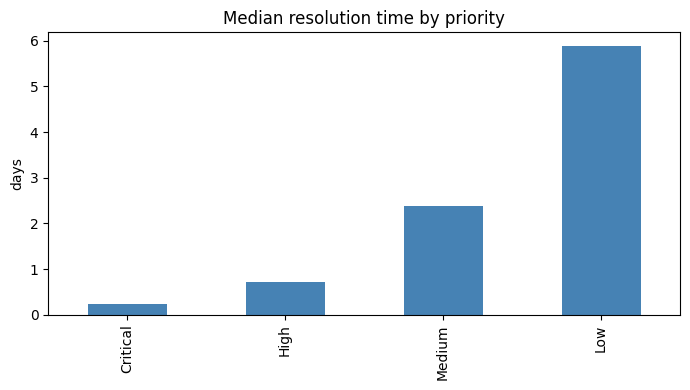

In [24]:
order = ["Critical", "High", "Medium", "Low"]
by_pri = timed.groupby("Priority")["resolution_days"].agg(["count", "median", "mean"]).reindex(order).round(2)
display(by_pri.style
        .format({"count": "{:.0f}", "median": "{:.2f}", "mean": "{:.2f}"}, na_rep="-")
        .set_caption("Median resolution time by priority (days), note Low is the SLOWEST"))

fig, ax = plt.subplots(figsize=(7, 4))
by_pri["median"].plot.bar(ax=ax, color="steelblue")
ax.set_title("Median resolution time by priority")
ax.set_ylabel("days"); ax.set_xlabel("")
plt.tight_layout(); plt.show()


In [25]:
# 2x the volume could be straining the team
# Split resolution by created-window, and by component, to see whether (and where) speed degraded after the release
# Did resolution slow after the release? (resolved tickets, split by created window)
tp, tq = timed[~timed["post_release"]], timed[timed["post_release"]]
print(f"Median resolution: pre {tp['resolution_days'].median():.2f}d  ->  post {tq['resolution_days'].median():.2f}d")
print()
shift = pd.DataFrame({
    "pre_median":  tp.groupby("Component")["resolution_days"].median(),
    "post_median": tq.groupby("Component")["resolution_days"].median(),
}).round(2)
shift["delta_days"] = (shift["post_median"] - shift["pre_median"]).round(2)
print("Median resolution by component, pre vs post-release (sorted by biggest slowdown):")
display(shift.sort_values("delta_days", ascending=False))

# Mildly overall (2.8 -> 3.0d); the slowdown sits in Account (+1.7d) and Search (+0.8d); Mobile improved

Median resolution: pre 2.79d  ->  post 3.00d

Median resolution by component, pre vs post-release (sorted by biggest slowdown):


,pre_median,post_median,delta_days
Component,,,
Account,3.04,4.71,1.67
Search,1.94,2.77,0.83
Payments,3.49,4.05,0.56
Checkout,2.55,2.85,0.30
Notifications,2.85,2.93,0.08
Reports,2.07,1.79,-0.28
Admin,4.62,4.20,-0.42
Mobile,3.53,2.45,-1.08


- Resolution is right-skewed (median 2.9d, max 71d)
- Post-release the team slowed only mildly overall (2.8→3.0d), with **Account (+1.7d)** and **Search (+0.8d)** absorbing most of the strain

## Reopens

- Wwhat % of tickets get reopened? Is the reopen rate concentrated anywhere?* 
- Reopen rate = share of tickets with `Reopen Count > 0` (computed over all tickets)

In [26]:
# reopens = "fixes that don't stick"
# Reopen rate = share of tickets reopened at least once (Reopen Count > 0), over all tickets
print(f"Overall reopen rate: {(df['Reopen Count'] > 0).mean():.1%}  "
      f"({int((df['Reopen Count'] > 0).sum())} of {len(df)} tickets reopened at least once)")
print()

def reopen_rate(col, min_n=1):
    g = df.groupby(col).agg(n=("Issue Key", "size"),
                            reopened=("Reopen Count", lambda s: int((s > 0).sum())))
    g["rate_%"] = (g["reopened"] / g["n"] * 100).round(1)
    return g[g["n"] >= min_n].sort_values("rate_%", ascending=False)

print("By component:")
display(reopen_rate("Component"))
print()
print("By priority:")
display(reopen_rate("Priority"))

# Overall 10.7%: Payments is the biggest concern at 25% (and by label, regression)

Overall reopen rate: 10.7%  (107 of 1000 tickets reopened at least once)

By component:


,n,reopened,rate_%
Component,,,
Payments,180,45,25.0
Search,186,22,11.8
Mobile,62,6,9.7
Admin,34,3,8.8
Reports,91,7,7.7
Account,127,9,7.1
Checkout,263,14,5.3
Notifications,57,1,1.8



By priority:


,n,reopened,rate_%
Priority,,,
High,140,25,17.9
Critical,38,5,13.2
Low,371,39,10.5
Medium,451,38,8.4


In [27]:
# Component and priority each move reopen rate
cp = df.groupby(["Component", "Priority"]).agg(
    n=("Issue Key", "size"),
    reopened=("Reopen Count", lambda s: int((s > 0).sum())),
)
cp["reopen_pct"] = (cp["reopened"] / cp["n"] * 100).round(1)
print("Component x Priority reopen rate (cells with >=10 tickets), worst first:")
display(cp[cp["n"] >= 10].sort_values("reopen_pct", ascending=False))
print(f"(dropped {int((cp['n'] < 10).sum())} of {len(cp)} cells with <10 tickets -- too small to read)")

# Payments reopens ~24-27% at every priority (Medium 27 / High 26 / Low 24, n=47-74) -> the reopen problem is the 
    # COMPONENT (Payments), not severity
# The two higher cells (Reports/High 31%, Search/Critical 27%) are only n=11-13 (3-4 reopens) -> noise, don't build on them

Component x Priority reopen rate (cells with >=10 tickets), worst first:


n  reopened  reopen_pct
Component     Priority                           
Reports       High       13         4        30.8
Search        Critical   11         3        27.3
Payments      Medium     74        20        27.0
              High       47        12        25.5
              Low        54        13        24.1
Search        Low        71         9        12.7
Admin         Low        16         2        12.5
Search        High       25         3        12.0
Checkout      High       27         3        11.1
Account       High       11         1         9.1
Search        Medium     79         7         8.9
Account       Low        57         5         8.8
Mobile        Low        28         2         7.1
Admin         Medium     14         1         7.1
Reports       Low        30         2         6.7
Checkout      Low        95         6         6.3
Mobile        Medium     25         1         4.0
Account       Medium     50         2         4.0
Checkout      Medium    137         5         3.6
Notifications Medium     29         1         3.4
Reports       Medium     43         1         2.3
Notifications Low        20         0         0.0

(dropped 9 of 31 cells with <10 tickets -- too small to read)


In [28]:
# Component/priority didn't fully explain the reopens (explore further: assignee, label,release window)
print("By assignee:")
display(reopen_rate("Assignee"))
print()

# By label (explode the multi-value label_list)
lab = df.explode("label_list")
lab = lab[lab["label_list"].notna() & (lab["label_list"] != "")]
bl = lab.groupby("label_list").agg(n=("Issue Key", "size"),
                                   reopened=("Reopen Count", lambda s: int((s > 0).sum())))
bl["rate_%"] = (bl["reopened"] / bl["n"] * 100).round(1)
print("By label (min 20 tickets):")
display(bl[bl["n"] >= 20].sort_values("rate_%", ascending=False))
print()

print("Pre vs post-release reopen rate:")
display((df.groupby(df["post_release"].map({False: "pre", True: "post"}))["Reopen Count"]
         .apply(lambda s: round((s > 0).mean() * 100, 1))))

# Label `regression` (51%) plus the post-release window (8.4% -> 11.8%)
# assignee gaps are modest

By assignee:


,n,reopened,rate_%
Assignee,,,
Gita Patel,114,18,15.8
Carla Singh,92,11,12.0
Felix Wong,110,13,11.8
Elena Ruiz,116,13,11.2
Alice Chen,242,25,10.3
Ben Ortiz,103,10,9.7
Henry Liu,94,9,9.6
Devon Park,104,7,6.7
Unassigned,25,1,4.0



By label (min 20 tickets):


,n,reopened,rate_%
label_list,,,
regression,96,49,51.0
mobile-only,52,11,21.2
ux,56,8,14.3
ui-bug,48,6,12.5
documentation,44,5,11.4
intermittent,46,4,8.7
p1-escalation,81,7,8.6
edge-case,49,4,8.2
data-quality,52,4,7.7



Pre vs post-release reopen rate:


post_release
post    11.8
pre      8.4
Name: Reopen Count, dtype: float64

- 10.7% of tickets reopen, but it's highly concentrated: **Payments (25%)** is the biggest for component and **`regression` (51%)** for label( fixes frequently fail) 
- Reopens rose post-release (8.4→11.8%)
- Assignee differences are modest and most likely reflect ticket mix rather than skill

### How often, and what the Payments reopens share?

- How *often* tickets reopen (once versus repeatedly), and whether the reopened Payments tickets are one issue or many

In [29]:
# How OFTEN tickets reopen (once vs repeatedly), and whether the reopened Payments tickets share anything or are all different:

# 1) Exact reopen multiplicity by component (a ticket can reopen up to 3 times)
#    tickets_reopened = distinct tickets that reopened at least once
total = df.groupby("Component").size()
mult = pd.crosstab(df["Component"], df["Reopen Count"])
mult["tickets_reopened"] = df[df["Reopen Count"] > 0].groupby("Component").size().reindex(mult.index).fillna(0).astype(int)
mult["reopen_rate_%"] = (mult["tickets_reopened"] / total * 100).round(1)
display(mult.sort_values("tickets_reopened", ascending=False)
        .style.set_caption("Reopens by component: columns 0/1/2/3 = tickets that reopened that many times"))

# 2) Payments reopens by summary: one ticket type, or spread out?
pay = df[df["Component"] == "Payments"]
pay_sum = pay.groupby("summary_norm").agg(
    tickets=("Issue Key", "size"),
    tickets_reopened=("Reopen Count", lambda s: int((s > 0).sum())),
)
pay_sum["reopen_rate_%"] = (pay_sum["tickets_reopened"] / pay_sum["tickets"] * 100).round(0)
display(pay_sum[pay_sum["tickets_reopened"] > 0].sort_values("tickets_reopened", ascending=False)
        .style.set_caption("Payments: reopened tickets by summary (spread across the whole component)"))

# 3) What the reopened Payments tickets have in common
ro = pay[pay["Reopen Count"] > 0]
reg_share = ro["label_list"].apply(lambda lst: "regression" in lst).mean() * 100
print(f"Reopened Payments tickets: {len(ro)}")
print(f"  labeled 'regression': {reg_share:.0f}%")
print(f"  created post-release:  {ro['post_release'].mean() * 100:.0f}%  (vs {pay['post_release'].mean() * 100:.0f}% of all Payments)")

# Rreopens are NOT one ticket, they span all 10 Payments summaries (the reliability ones like Apple Pay
# button, gateway timeout, Stripe webhook reopen most, 33-54%). What they share: 100% are 'regression'-labeled
# and 76% are post-release

# Common thread is regressions concentrated after the release

Reopen Count,0,1,2,3,tickets_reopened,reopen_rate_%
Component,,,,,,
Payments,135,25,16,4,45,25.000000
Search,164,15,4,3,22,11.800000
Checkout,249,10,3,1,14,5.300000
Account,118,7,1,1,9,7.100000
Reports,84,6,1,0,7,7.700000
Mobile,56,3,3,0,6,9.700000
Admin,31,2,1,0,3,8.800000
Notifications,56,1,0,0,1,1.800000


,tickets,tickets_reopened,reopen_rate_%
summary_norm,,,
Apple Pay button missing,13,7,54.000000
Payment fails with 'gateway timeout',20,7,35.000000
Stripe webhook not received,21,7,33.000000
3DS challenge loops infinitely,23,5,22.000000
Show payment plan options,22,5,23.000000
Card declined but money held,26,4,15.000000
Refund not processed within 7 days,24,4,17.000000
Add support for ACH,11,3,27.000000
Display refund timeline,11,2,18.000000


Reopened Payments tickets: 45
  labeled 'regression': 100%
  created post-release:  76%  (vs 64% of all Payments)


## Backlog snapshot (open tickets)

- Snapshot of what's currently open
- Age = days from `Created` to the data's reference date (2026-06-07)

In [30]:
# 14% are still open: are they fresh or rotting? 
# Age each open ticket (now - created) and group by component to surface stale backlog
open_t = df[df["status_clean"] != "Resolved"].copy()
REF = pd.Timestamp("2026-06-07")                       # data reference date
open_t["age_days"] = (REF - open_t["Created"]).dt.total_seconds() / 86400

print(f"Open tickets: {len(open_t)}  ({len(open_t)/len(df):.0%} of all)")
print("\nBy status label:")
display(open_t["status_clean"].value_counts())

print("\nOpen count + median age (days) by component:")
g = open_t.groupby("Component").agg(open_n=("Issue Key", "size"), median_age=("age_days", "median"))
g["median_age"] = g["median_age"].round(0)
display(g.sort_values("open_n", ascending=False))

print("\nOpen by priority:")
display(open_t.groupby("Priority").size().reindex(["Critical", "High", "Medium", "Low"]))

# Partly rotting: Reports (240d) and Notifications (248d) open items are ~8 months old; 21 High + 5 Critical still open

Open tickets: 135  (14% of all)

By status label:


status_clean
In Progress    48
Open           48
In Review      39
Name: count, dtype: int64


Open count + median age (days) by component:


,open_n,median_age
Component,,
Checkout,32,143.0
Payments,24,154.0
Search,24,191.0
Account,22,134.0
Reports,15,240.0
Notifications,10,248.0
Mobile,6,197.0
Admin,2,279.0



Open by priority:


Priority
Critical     5
High        21
Medium      68
Low         41
dtype: int64

- 135 tickets (14%) are open, split fairly evenly across the three open labels
- The real concern is age: Reports (240d) and Notifications (248d) open items are ~8 months old, a stale, mostly low-priority tail that won't clear without an explicit aging rule. The 21 High + 5 Critical still open also warrant a triage sweep

## Assignee load

In [31]:
# Is work evenly distributed?
load = df[df["Assignee"] != "Unassigned"]["Assignee"].value_counts()
print("Tickets assigned per person:")
display(load)
print(f"\nBusiest: {load.index[0]} = {load.iloc[0]}  |  median assignee = {load.median():.0f}  "
      f"|  busiest carries {load.iloc[0] / load.median():.1f}x the median load")

# Load is uneven, the busiest assignee carries ~2x the median assignee's load (Alice)

Tickets assigned per person:


Assignee
Alice Chen     242
Elena Ruiz     116
Gita Patel     114
Felix Wong     110
Devon Park     104
Ben Ortiz      103
Henry Liu       94
Carla Singh     92
Name: count, dtype: int64


Busiest: Alice Chen = 242  |  median assignee = 107  |  busiest carries 2.3x the median load


Work is unevenly distributed: the busiest assignee carries about **2× the median load**

## Customers

- Is any single customer driving disproportionate volume?

In [32]:
# Is any single customer flooding the queue?
cust = df["Customer"].value_counts()
print("Tickets per customer:")
display(cust)
print(f"\nTop customer: {cust.index[0]} = {cust.iloc[0] / len(df):.1%} of all; "
      f"spread (max/min) = {cust.max() / cust.min():.1f}x")

# No, largest customer is ~16.5% (~1.5x the next); spread only ~2x

Tickets per customer:


Customer
Acme Corp            165
Umbrella Holdings    112
Cyberdyne Systems    100
Initech               98
Pied Piper            97
Stark Enterprises     96
Dunder Mifflin        91
Wayne Industries      83
Globex Industries     79
Hooli Inc             79
Name: count, dtype: int64


Top customer: Acme Corp = 16.5% of all; spread (max/min) = 2.1x


- No customer-concentration risk: the largest customer is about **16.5%** of volume (roughly 1.5× the next) and the full spread is only about 2×
- Volume is spread evenly, so the customer dimension is not a driver of the workload

### Label coverage & reliability

The label cuts that follow only cover the **~60% of tickets that are labeled**

In [33]:
has = df["Labels"].notna()
print(f"Labeled: {int(has.sum())} ({has.mean()*100:.0f}%)  |  unlabeled: {int((~has).sum())} ({(~has).mean()*100:.0f}%)")
print("\nLabel coverage by component (fairly even ~57-67% -> label comparisons not badly skewed):")
display(df.groupby("Component")["Labels"].apply(lambda s: round(s.notna().mean() * 100, 0))
        .sort_values(ascending=False).rename("labeled_%").to_frame())

pay = df[df["Component"] == "Payments"]
preg = df.explode("label_list"); preg = preg[(preg["Component"] == "Payments") & (preg["label_list"] == "regression")]
all_re = (pay["Reopen Count"] > 0).mean() * 100
k_, n_ = int((preg["Reopen Count"] > 0).sum()), len(preg)
p = k_ / n_
z = 1.96  
center = (p + z*z/(2*n_)) / (1 + z*z/n_)
half = z * ((p*(1-p)/n_ + z*z/(4*n_*n_)) ** 0.5) / (1 + z*z/n_)
print(f"\nPayments reopen -- ALL {len(pay)} tickets (label-INDEPENDENT): {all_re:.1f}%   <- the robust foundation")
print(f"Payments tagged-regression SUBSET: {k_}/{n_} = {p*100:.1f}%  (95% CI ~{(center-half)*100:.0f}-{(center+half)*100:.0f}%)")
print(f"Baseline reopen, all tickets: {(df['Reopen Count']>0).mean()*100:.1f}%")

# ~60% labeled, even across components
# The 86.5% is a 52-ticket subset but the effect is large & statistically solid 
# Tagging is voluntary, so untagged regressions likely exist and the rate may be mildly inflated

Labeled: 602 (60%)  |  unlabeled: 398 (40%)

Label coverage by component (fairly even ~57-67% -> label comparisons not badly skewed):


,labeled_%
Component,
Notifications,67.0
Payments,64.0
Account,62.0
Admin,62.0
Reports,59.0
Search,59.0
Mobile,58.0
Checkout,57.0



Payments reopen -- ALL 180 tickets (label-INDEPENDENT): 25.0%   <- the robust foundation
Payments tagged-regression SUBSET: 45/52 = 86.5%  (95% CI ~75-93%)
Baseline reopen, all tickets: 10.7%


## Label severity & reopen drivers

- Priority×Labels: labels signal severity (Critical/High share) and which signal fragility (reopen rate)

In [34]:
# "severe" and "keeps reopening" might be different things. Score each label on both
# Critical/High share and reopen rate, to separate severity from fragility
# Labels ranked as severity drivers (Critical/High share) and trouble drivers (reopen rate)
lab = df.explode("label_list")
lab = lab[lab["label_list"].notna() & (lab["label_list"] != "")]
sev = lab.groupby("label_list").agg(
    n=("Issue Key", "size"),
    pct_crit_high=("Priority", lambda s: (s.isin(["Critical", "High"])).mean() * 100),
    reopen_pct=("Reopen Count", lambda s: (s > 0).mean() * 100),
).round(1)
print("Labels by severity (Critical/High %), min 20 tickets:")
display(sev[sev["n"] >= 20].sort_values("pct_crit_high", ascending=False))
print("\nFor reference, Issue Type severity (Critical/High %):")
display(df.groupby("Issue Type")["Priority"].apply(lambda s: round((s.isin(["Critical", "High"])).mean() * 100, 1)))

# The reopen story collapses onto a single component x label pocket
pr = lab[(lab["Component"] == "Payments") & (lab["label_list"] == "regression")]
print(f"\nPayments x regression: {int((pr['Reopen Count'] > 0).sum())} of {len(pr)} reopen "
      f"= {(pr['Reopen Count'] > 0).mean() * 100:.1f}% (far above any other component+label pocket)")

# p1-escalation is severe (56% Crit/High), regression is fragile (51% reopen,
# only 17% Crit/High)
# Reopen collapses onto Payments x regression at 86.5% (a labeled subset)

Labels by severity (Critical/High %), min 20 tickets:


,n,pct_crit_high,reopen_pct
label_list,,,
p1-escalation,81,55.6,8.6
data-quality,52,25.0,7.7
mobile-only,52,25.0,21.2
security,43,23.3,7.0
documentation,44,22.7,11.4
api,46,21.7,4.3
intermittent,46,21.7,8.7
regression,96,16.7,51.0
ui-bug,48,14.6,12.5



For reference, Issue Type severity (Critical/High %):


Issue Type
Feedback           3.7
Reported Issue    24.4
Subtask           20.0
Name: Priority, dtype: float64


Payments x regression: 45 of 52 reopen = 86.5% (far above any other component+label pocket)


- `p1-escalation` (56% Critical/High) flags severe tickets (an escalation tag) 
- `regression` is only mid-severity (17%) but the most fragile (51% reopen): regressions aren't necessarily urgent, they just don't stay fixed
- `mobile-only` scores high on both. 
- This is a label-dependent subset (only the ~60% labeled tickets, with voluntary-tagging bias), so read as pointer

## Component severity, pre vs post-release

- Component×Priority: did the release shift where severe (Critical/High) tickets come from?

In [35]:
# Release shifted volume by component -> did it also shift severity?
# Compare each component's Critical/High share pre vs post
def crit_high_share(frame):
    return frame.groupby("Component")["Priority"].apply(lambda s: (s.isin(["Critical", "High"])).mean() * 100)

csev = pd.DataFrame({
    "pre_crit_high_%": crit_high_share(pre).round(1),
    "post_crit_high_%": crit_high_share(post).round(1),
})
csev["delta_pts"] = (csev["post_crit_high_%"] - csev["pre_crit_high_%"]).round(1)
print("Share of a component's tickets that are Critical/High, pre vs post-release:")
display(csev.sort_values("delta_pts", ascending=False))

# Admin (+17 pts), Checkout (+6.5), Account (+3.8) got more severe
# Payments/Search share fell (dilution; Payments still highest at 27%)

Share of a component's tickets that are Critical/High, pre vs post-release:


,pre_crit_high_%,post_crit_high_%,delta_pts
Component,,,
Admin,0.0,17.4,17.4
Checkout,7.3,13.8,6.5
Account,13.3,17.1,3.8
Notifications,12.0,15.6,3.6
Reports,19.4,20.0,0.6
Mobile,15.0,14.3,-0.7
Search,22.6,18.0,-4.6
Payments,32.3,27.0,-5.3


- The release raised the severity of **Admin (+17 pts**, small n), **Checkout (+6.5)**, **Account (+3.8)** and **Notifications (+3.6)**, more of their tickets are now Critical/High
- Payments and Search fell in severity share, but that's dilution by extra low-priority volume, not improvement 

## Net backlog growth

- Created vs resolved per month: is the team keeping up, especially after the release?

,created,resolved,net,cumulative_backlog
2025-01-01,25,16,9,9
2025-02-01,40,32,8,17
2025-03-01,33,25,8,25
2025-04-01,35,32,3,28
2025-05-01,49,47,2,30
2025-06-01,42,39,3,33
2025-07-01,39,36,3,36
2025-08-01,31,25,6,42
2025-09-01,38,33,5,47
2025-10-01,89,69,20,67


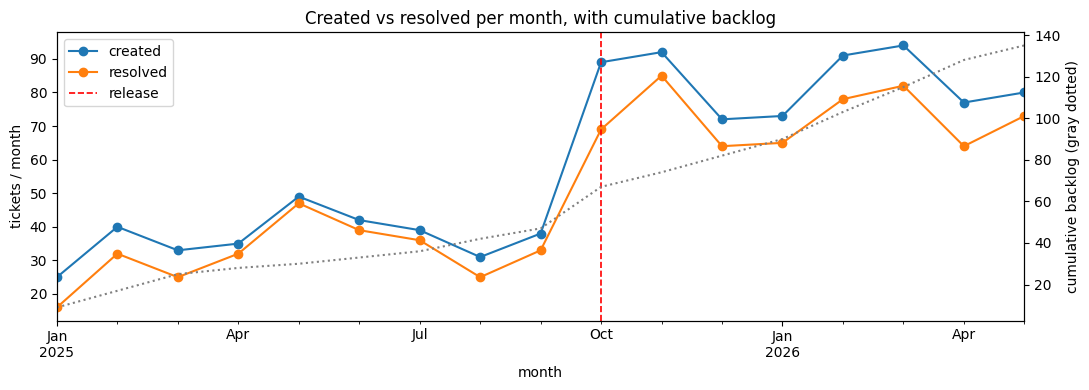

In [36]:
# Backlog grows whenever created > resolved:"are we keeping up?" 
created_m = df.groupby(df["Created"].dt.to_period("M").dt.to_timestamp()).size()
rdf = df[df["Resolved"].notna()]
resolved_m = rdf.groupby(rdf["Resolved"].dt.to_period("M").dt.to_timestamp()).size()
bal = pd.DataFrame({"created": created_m, "resolved": resolved_m}).fillna(0)
bal["net"] = bal["created"] - bal["resolved"]
bal["cumulative_backlog"] = bal["net"].cumsum()
display(bal.astype(int))

fig, ax = plt.subplots(figsize=(11, 4))
bal[["created", "resolved"]].plot(ax=ax, marker="o")
ax.axvline(RELEASE, color="red", ls="--", lw=1.2, label="release")
ax.set_ylabel("tickets / month"); ax.set_xlabel("month")
ax2 = ax.twinx()
bal["cumulative_backlog"].plot(ax=ax2, color="gray", ls=":")
ax2.set_ylabel("cumulative backlog (gray dotted)")
ax.set_title("Created vs resolved per month, with cumulative backlog")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

# No: created > resolved every month; cumulative backlog climbs 9 -> 135, steepening at the release

- Created exceeds resolved in every month, so the backlog only grows, cumulatively ~9 → 135, with a visible steepening at the release (net +20 in Oct)
- The team holds median resolution roughly stable, but only by never closing the gap

## Recurring issues (Summary column)

- Summary is heavily templated (77 unique / 1000), so we treat it as a recurring-issue key rather than free text

### Is `Summary` free text or templated?


In [37]:
# Summary looks specific -> count uniques and the repetition distribution first
import re
s = df["Summary"]
vc = s.value_counts()
print(f"Rows: {len(s)}  |  unique summaries: {s.nunique()}")
print("\nHow many summaries repeat exactly N times:")
rep = vc.value_counts().sort_index().rename_axis("appears_N_times").to_frame("num_summaries")
display(rep)
print(f"\nTemplates repeating >=10 times: {(vc >= 10).sum()} summaries, "
      f"covering {int(vc[vc >= 10].sum())} of {len(s)} rows ({vc[vc >= 10].sum()/len(s):.0%}).")
print(f"Summaries appearing exactly once (near-unique): {int((vc == 1).sum())}")

# The few near-unique strings embed a VARIABLE token (order number / state code).
specific = [x for x in vc[vc <= 2].index
            if re.search(r"#?\d", x) or re.search(r" (WA|CA|IL|MA|TX|NY)\b", x)]
print("\nThe 'specific'-looking summaries are templates with a variable token:")
display(s[s.isin(specific)].value_counts())

# Repeats: 77 unique / 1000, 43 templates cover 85% of rows; only 9 near-unique (order#/state)

# Derive the variable-token families programmatically: a normalized stem (summary_norm) that
# maps to >1 raw spelling is a template that exact-grouping would scatter
collapsed = df["Summary"].groupby(df["summary_norm"]).nunique()
print("\nVariable-token families (normalized stem -> # of raw variants it hides):")
print(collapsed[collapsed > 1].to_string())

Rows: 1000  |  unique summaries: 77

How many summaries repeat exactly N times:


,num_summaries
appears_N_times,
1,9
2,3
3,5
4,2
5,2
6,2
7,5
8,3
9,3



Templates repeating >=10 times: 43 summaries, covering 854 of 1000 rows (85%).
Summaries appearing exactly once (near-unique): 9

The 'specific'-looking summaries are templates with a variable token:


Summary
Tax calculation off for MA           2
Tax calculation off for CA           2
Duplicate charge for order #93453    1
Duplicate charge for order #91927    1
Duplicate charge for order #93518    1
Duplicate charge for order #33253    1
Duplicate charge for order #62552    1
Duplicate charge for order #61505    1
Duplicate charge for order #28101    1
Duplicate charge for order #51906    1
Duplicate charge for order #91528    1
Name: count, dtype: int64


Variable-token families (normalized stem -> # of raw variants it hides):
summary_norm
Duplicate charge for order #N      9
Tax calculation off for {STATE}    7


- `Summary` is **templated, not free text**: 77 unique strings across 1,000 rows, and 43 templates (each repeating 10+ times) cover ~85% of rows, so exact-match `groupby("Summary")` is a valid recurring-issue key for the bulk
- The only near-unique rows embed a variable token (`order #…`, `for {state}`)

In [38]:
# Now that summaries are shown to repeat, treat each as a recurring-issue key and profile volume, severity, reopen, speed, etc. -> 
# turning free text into a ranked problem list
rec = df.groupby("summary_norm").agg(
    n=("Issue Key", "size"),
    top_component=("Component", lambda s: s.mode().iat[0]),
    pct_crit_high=("Priority", lambda s: round((s.isin(["Critical", "High"])).mean() * 100, 1)),
    reopen_pct=("Reopen Count", lambda s: round((s > 0).mean() * 100, 1)),
    median_days=("resolution_days", "median"),
)
rec["median_days"] = rec["median_days"].round(1)
top = rec.sort_values("n", ascending=False).head(15)
display(top.style
        .format({"pct_crit_high": "{:.1f}", "reopen_pct": "{:.1f}", "median_days": "{:.1f}"}, na_rep="-")
        .set_caption("Top 15 recurring issues by volume (variable tokens normalized)"))

# Ttop recurring are Checkout-heavy (discount code 40, Apple Pay 29) plus high-severity Payments/Account (Refund 38% Crit/High, MFA 35%)

,n,top_component,pct_crit_high,reopen_pct,median_days
summary_norm,,,,,
Discount code not applying at checkout,40,Checkout,10.0,5.0,2.0
Please add Apple Pay,29,Checkout,0.0,3.4,3.9
Promo code stacking allowed,28,Checkout,17.9,0.0,2.0
Checkout button unresponsive on Safari,28,Checkout,10.7,3.6,3.9
Search ranking buries new products,27,Search,29.6,14.8,1.6
Allow guest checkout,27,Checkout,7.4,3.7,3.4
Cart total shows incorrect amount,27,Checkout,18.5,14.8,3.8
MFA code never arrives,26,Account,34.6,7.7,2.0
Report scheduling never fires,26,Reports,23.1,7.7,1.9


In [39]:
# Which specific issues did the release amplify? 
# Compare each summary's monthly rate before vs after the release
chg = pd.DataFrame({
    "pre_per_mo": pre["Summary"].value_counts() / pre_months,
    "post_per_mo": post["Summary"].value_counts() / post_months,
}).fillna(0).round(2)
chg["rate_change"] = (chg["post_per_mo"] - chg["pre_per_mo"]).round(2)
chg["component"] = df.groupby("Summary")["Component"].agg(lambda s: s.mode().iat[0])
print("Recurring issues that grew most post-release (by monthly-rate change):")
display(chg[["component", "pre_per_mo", "post_per_mo", "rate_change"]]
        .sort_values("rate_change", ascending=False).head(12))

# Amplified flows are Checkout (Safari button +2.3/mo, cart empties +1.6), Payments (card declined +1.6), and Search (autocomplete slow +1.6)

Recurring issues that grew most post-release (by monthly-rate change):


,component,pre_per_mo,post_per_mo,rate_change
Summary,,,,
Checkout button unresponsive on Safari,Checkout,0.56,2.88,2.32
Card declined but money held,Payments,0.78,2.38,1.60
Autocomplete slow (>3s),Search,0.67,2.25,1.58
Cart empties on page refresh,Checkout,0.56,2.12,1.56
Search returns no results for valid query,Search,0.22,1.75,1.53
Cart total shows incorrect amount,Checkout,0.89,2.38,1.49
Discount code not applying at checkout,Checkout,1.67,3.12,1.45
Filter by price not working,Search,0.67,2.12,1.45
Order confirmation email not sent,Checkout,0.44,1.88,1.44


- Top recurring problems are overwhelmingly **Checkout** (discount codes, Safari button, guest checkout) plus a few high-severity **Payments/Account** items (*Refund not processed* 38% Crit/High; *MFA never arrives* 35%) 
- The pre/post diff is the actionable part: the release sharply amplified specific flows, **Checkout button unresponsive on Safari (+2.3/mo)** and **Card declined but money held (+1.6/mo)** lead, concrete regressions to investigate first

### Financial-correctness regressions

In [40]:
# Financial-correctness regressions = customer charged/refunded the WRONG amount, or money taken/held incorrectly
charge_correctness = [ # which normalized summaries are money-wrong
    "Card declined but money held",
    "Duplicate charge for order #N",
    "Refund not processed within 7 days",
    "Cart total shows incorrect amount",
    "Tax calculation off for {STATE}",
]
pm, qm = 9, 8
rows = []
for norm in charge_correctness:
    s = df[df["summary_norm"] == norm]
    pre, post = int((~s["post_release"]).sum()), int(s["post_release"].sum())
    rows.append({"charge-correctness bug": norm, "component": s["Component"].mode().iat[0],
                 "before": pre, "after": post,
                 "increase": (f"{(post/qm)/(pre/pm):.1f}x" if pre else "new")})
display(pd.DataFrame(rows).set_index("charge-correctness bug"))
# 5 charge-correctness regressions, all ~2.4-4x post-release, across Payments (card held, duplicate
# charge, refund-not-processed) and Checkout (cart total wrong, tax-by-state)

,component,before,after,increase
charge-correctness bug,,,,
Card declined but money held,Payments,7,19,3.1x
Duplicate charge for order #N,Payments,2,7,3.9x
Refund not processed within 7 days,Payments,7,17,2.7x
Cart total shows incorrect amount,Checkout,8,19,2.7x
Tax calculation off for {STATE},Checkout,6,13,2.4x


Three more views built on the templated `Summary` field:
- (1) most-requested features
- (2) a pain-score ranking of recurring Reported Issues
- (3) issues the release introduced/concentrated

In [41]:
# Feedback = feature requests
# Rank those summaries to read demand as a product roadmap kept separate from the Reported-Issue analysis
# 1) Product-roadmap signal: top Feedback (feature-request) summaries + how they grew post-release
fb = df[df["Issue Type"] == "Feedback"]
req = fb.groupby("Summary").agg(
    requests=("Issue Key", "size"),
    top_component=("Component", lambda s: s.mode().iat[0]),
)
req["pre_per_mo"] = fb[~fb["post_release"]].groupby("Summary").size() / pre_months
req["post_per_mo"] = fb[fb["post_release"]].groupby("Summary").size() / post_months
req = req.fillna(0)
req["rate_change"] = (req["post_per_mo"] - req["pre_per_mo"]).round(2)
print("Top requested features (Feedback summaries):")
display(req.sort_values("requests", ascending=False).head(12)[["requests", "top_component", "rate_change"]])

# Ddemand is Checkout-centric: Apple Pay (29), guest checkout (27), show shipping cost earlier (24) top the list

Top requested features (Feedback summaries):


,requests,top_component,rate_change
Summary,,,
Please add Apple Pay,29,Checkout,1.26
Allow guest checkout,27,Checkout,1.25
Show shipping cost earlier,24,Checkout,1.11
Add filter for in-stock only,24,Search,0.88
Suggest related products,23,Search,1.22
Show payment plan options,22,Payments,1.10
Allow saved searches,14,Search,0.81
Add SSO support,13,Account,0.21
Send welcome email,12,Account,0.56


In [42]:
# Combine volume x severity x reopen into one score so"most painful" can beat "most common".
# 2) Pain score for recurring Reported Issues = volume x severity x reopen (each min-max normalized, equal weight)
reported = df[df["Issue Type"] == "Reported Issue"]
p = reported.groupby("Summary").agg(
    component=("Component", lambda s: s.mode().iat[0]),
    n=("Issue Key", "size"),
    crit_high_pct=("Priority", lambda s: (s.isin(["Critical", "High"])).mean() * 100),
    reopen_pct=("Reopen Count", lambda s: (s > 0).mean() * 100),
    median_days=("resolution_days", "median"),
)
p = p[p["n"] >= 8].copy()
for col in ["n", "crit_high_pct", "reopen_pct"]:
    lo, hi = p[col].min(), p[col].max()
    p[col + "_z"] = 0.0 if hi == lo else (p[col] - lo) / (hi - lo)
p["pain_score"] = ((p["n_z"] + p["crit_high_pct_z"] + p["reopen_pct_z"]) / 3 * 100).round(0)
out = p[["component", "n", "crit_high_pct", "reopen_pct", "median_days", "pain_score"]].round(1)
top = out.sort_values("pain_score", ascending=False).head(12)
display(top.style
        .format({"crit_high_pct": "{:.1f}", "reopen_pct": "{:.1f}", "median_days": "{:.1f}", "pain_score": "{:.0f}"}, na_rep="-")
        .set_caption("Recurring Reported Issues by pain score (relative 0-100; volume x severity x reopen, min 8)"))

# Ranking is topped by Payments-component issues: Stripe webhook (62), gateway timeout (61), Apple Pay button (60, 58% reopen)
# The component column shows the top is Payment

,component,n,crit_high_pct,reopen_pct,median_days,pain_score
Summary,,,,,,
Stripe webhook not received,Payments,19,42.1,36.8,3.0,62
Payment fails with 'gateway timeout',Payments,18,50.0,27.8,6.1,61
Apple Pay button missing,Payments,12,33.3,58.3,3.7,60
Misspelled query returns 0 results,Search,15,46.7,33.3,2.5,58
Refund not processed within 7 days,Payments,22,40.9,18.2,4.3,54
3DS challenge loops infinitely,Payments,21,33.3,23.8,2.3,51
Card declined but money held,Payments,24,29.2,12.5,2.3,46
Search ranking buries new products,Search,24,25.0,12.5,1.7,43
Date filter ignored in revenue report,Reports,19,31.6,15.8,2.6,43


- The feature view is a clean product backlog, *Apple Pay*, *guest checkout*, and *in-stock filter* are the most-asked, and several grew post-release (users hitting the new flows want more)
- The pain-score reorders the Reported-Issue list away from raw frequency toward what actually hurts (*Refund not processed*, *Card declined but money held*, *MFA never arrives* rise to the top on severity + reopen)
- The release both **amplified** existing issues and **amplified** charge-correctness regressions
- **payment + checkout** is where the regression-reopen problem lives

### Where should engineering focus, volume vs risk?

"Biggest component" isn't automatically "where engineering should focus."

In [43]:
prio = df.groupby("Component").agg(
    volume=("Issue Key", "size"),
    pct_feature_req=("Issue Type", lambda s: round((s == "Feedback").mean() * 100, 1)),
    pct_defect=("Issue Type", lambda s: round((s == "Reported Issue").mean() * 100, 1)),
    reopen_pct=("Reopen Count", lambda s: round((s > 0).mean() * 100, 1)),
    crit_high_pct=("Priority", lambda s: round((s.isin(["Critical", "High"])).mean() * 100, 1)),
)
# Of each component's defects, how many bounce back?
dfx = df[df["Issue Type"] == "Reported Issue"]
prio["defect_reopen_pct"] = dfx.groupby("Component")["Reopen Count"].apply(lambda s: round((s > 0).mean() * 100, 1))
prio["reopened_defects"] = dfx.groupby("Component")["Reopen Count"].apply(lambda s: int((s > 0).sum()))
display(prio.sort_values("volume", ascending=False)
        .style.set_caption("Components: volume vs engineering-risk signals"))
# Checkout is biggest but fixes hold (defect-reopen ~6%) and ~30% is feature requests -> VOLUME/INFLOW
# Payments is smaller but fixes fail (defect-reopen 25%, 31 reopened) + most severe + financial -> RISK/REWORK

,volume,pct_feature_req,pct_defect,reopen_pct,crit_high_pct,defect_reopen_pct,reopened_defects
Component,,,,,,,
Checkout,263,30.400000,58.900000,5.300000,11.800000,5.800000,9
Search,186,32.800000,57.500000,11.800000,19.400000,12.100000,13
Payments,180,24.400000,68.300000,25.000000,28.900000,25.200000,31
Account,127,26.800000,64.600000,7.100000,15.700000,6.100000,5
Reports,91,25.300000,63.700000,7.700000,19.800000,8.600000,5
Mobile,62,38.700000,53.200000,9.700000,14.500000,12.100000,4
Notifications,57,38.600000,49.100000,1.800000,14.000000,3.600000,1
Admin,34,29.400000,61.800000,8.800000,11.800000,9.500000,2


## K. Findings and Recommendations

> **Most business-critical:** the release **amplified charge-correctness regressions**, the product charging/refunding the *wrong amount*, across **Payments + Checkout**: card-declined-but-money-held **7→19**, duplicate charge **2→7**, refund-not-processed **7→17** (Payments); cart-total-wrong **8→19**, tax-calc-off **6→13** (Checkout). All ~2.4-4× more frequent post-release.

### Top findings
1. **The Oct-1 release caused a permanent step-change in volume.** Run-rate jumped 37 → 84 tickets/mo (+126%); Reported Issues grew fastest (+132%); mix tilted toward Search (+3.9 pts) and Checkout (+2.4 pts).
2. **Fixes don't stick, Payments is where most reopens occur.** **Payments reopens 25% of *all* its tickets**, the worst component by 2×+, vs 10.7% overall. Sharper but *label-dependent*: of the 52 Payments tickets **tagged** `regression`, **86.5% reopen** (a subset, see the labeling caveat). Reopen rose 8.4% → 11.8% post-release.
3. **The team never catches up.** Created exceeds resolved *every month*; cumulative open backlog climbed ~9 → 135, steepening right at the release (net +20 in Oct).
4. **The release amplified, and in places *introduced*, Checkout/Payments issues.** Money-mishandling (wrong-amount) issues all jumped ~2.4-4×: *Card declined but money held* **7→19**, *Duplicate charge* **2→7**, *Refund not processed* **7→17** (Payments); *Cart total shows incorrect amount* **8→19**, *Tax calculation off* **6→13** (Checkout). Plus UX regressions like *Safari checkout button* (+2.3/mo).
5. **Highest-pain recurring Reported Issues are Payments-component (calling them 'payment infrastructure' is an assumption).** By a volume×severity×reopen score: *Stripe webhook not received*, *Payment fails 'gateway timeout'*, *Apple Pay button missing* (58% reopen), *Refund not processed*.
6. **Volume ≠ where engineering is failing.** Checkout (263, the biggest) and Search (186, the fastest-growing, share +3.9 pts and about 2.5×) are **volume/inflow** loads: their defects reopen only ~6% and ~12%, so fixes hold. Payments is smaller (180) but its defects reopen **25%** (31 of 123) and it's the most severe (29% Critical/High) with financial failures, a **risk/rework** problem.
7. **Triage starves low priority.** Median resolution Critical 0.2d → Low 5.9d; Reports/Notifications backlog is ~240+ days old.
8. **Other:** Clear product demand: *Apple Pay* (29), *guest checkout* (27), *show shipping cost earlier* (24).

### Recommendation, where engineering should focus next quarter
Ranked, because the three top components are different problems: **Payments** is a quality and money problem to fix, while **Checkout** and **Search** are volume and inflow to manage.

**1. Payments (priority), highest *risk per ticket* (quality debt + money).** Lower volume (180) and a shrinking share, but fixes fail, **Payments reopens 25%** (worst component; the tagged-regression slice is 86.5%), it's the most severe component (29% Critical/High), and its failures are financial (duplicate charges, card-declined-but-held, wrong tax). This is where where business cost is highest.

**2. Checkout, the biggest component (263).** Its defects reopen only ~6%, fixes *hold*, and ~30% is feature requests, so it's not a quality crisis. The lever is **reducing inflow**, not rework: the release regressions plus the top feature requests.

**3. Search, the fastest-growing component (186, share +3.9 pts, about 2.5× post-release).** Its tickets reopen only ~12%, fixes mostly hold, so it's **inflow** too: a mix of quality issues (*Autocomplete slow*, *Filter by price not working*, *Misspelled query returns 0 results*) and feature requests (*in-stock filter*, *suggest related products*, *ranking*).

**Cross-cutting (secondary).** Capacity: created exceeds resolved every month and reopens degraded post-release, so raise throughput and rebalance the overloaded assignee and the Monday spike. And drain the aging low-priority Reports/Notifications tail (~8 months old).

### Where to start

- **Payments, fixes aren't sticking (25% reopen).** Dig into the tickets that keep recurring/reopening: *Stripe webhook not received*, *Payment fails 'gateway timeout'*, *Card declined but money held*, *3DS challenge loops*, *Refund not processed*, and the brand-new post-release ones, *Duplicate charge for order #…* and *Tax calculation off for WA/IL/CA* (financial **and** new → top priority).
- **Checkout, fixes already hold (~6% reopen), so it's volume, not rework.** The release-amplified regressions *Checkout button unresponsive on Safari* and *Cart empties on page refresh*; plus the top feature requests *Apple Pay*, *guest checkout*, *show shipping cost earlier*.
- **Search, fixes mostly hold (~12% reopen), so it's volume too.** The quality issues *Autocomplete slow*, *Filter by price not working*, *Misspelled query returns 0 results*; plus the top requests *in-stock filter*, *suggest related products*, *ranking buries new products*.
- **Backlog / load:** the ~8-month-old Reports/Notifications open tickets, and the Monday-intake / single-overloaded-assignee load.

### Next-quarter sequencing

- **Weeks 1-2 (fix first):** the charge-correctness bugs, duplicate charges, declined-but-held, refund-not-processed (Payments), wrong cart totals / tax (Checkout).
- **Across the quarter:** get Payments fixes to stick; then reduce Checkout and Search inflow (clear the regressions and ship one or two top features in each).
- **Continuous:** drain the old Reports/Notifications backlog

### Caveats
- No status-history → current snapshots, not flow (where tickets get stuck)
- **Label cuts cover only the labeled ~60%** (398 unlabeled), so a missing label ≠ the property is absent, and voluntary tagging can bias rates, e.g. the 86.5% regression-reopen is *among tickets tagged regression* (52 of 180 Payments) and may be inflated. The robust findings are **label-independent** (component reopen, resolution, recurring `Summary`)

## Appendix (Extra):

Cuts not shown in the main Analysis, kept for reference

**First-look summaries** (post-clean).

In [44]:
df.describe()

,Created,Resolved,Reopen Count,Comment Count,resolution_hours,resolution_days
count,1000,865,1000.00000,1000.00000,862.000000,862.000000
mean,2025-11-06 00:15:24.440000,2025-11-08 14:15:33.525162,0.15400,2.14700,120.498833,5.020785
min,2025-01-01 15:18:25,2025-01-02 21:29:03.272000,0.00000,0.00000,1.627999,0.067833
25%,2025-07-18 03:22:29.500000,2025-07-19 16:45:54.876000,0.00000,1.00000,31.926906,1.330288
50%,2025-11-24 14:23:50.500000,2025-11-27 13:12:46.279000,0.00000,2.00000,70.696927,2.945705
75%,2026-03-01 09:41:38.250000,2026-03-01 21:53:02.789000,0.00000,3.00000,146.719503,6.113313
max,2026-05-31 10:11:20,2026-05-30 22:00:00,3.00000,8.00000,1710.255915,71.260663
std,NaN,NaN,0.49247,1.81623,154.142518,6.422605


In [45]:
df.isnull().sum()


Issue Key             0
Issue Type            0
Summary               0
Status                0
Priority              0
Component             0
Reporter              0
Assignee              0
Customer              0
Created               0
Resolved            135
Reopen Count          0
Labels              398
Comment Count         0
status_clean          0
resolution_hours    138
resolution_days     138
is_subtask            0
label_list            0
created_month         0
created_dow           0
post_release          0
summary_norm          0
dtype: int64

In [46]:
status_counts = df["status_clean"].value_counts().reset_index()
status_counts.columns = ["Status", "Count"]

status_counts

,Status,Count
0,Resolved,865
1,In Progress,48
2,Open,48
3,In Review,39


**Customer × Priority**, severity mix by customer.

In [47]:
customer_priority = pd.crosstab(
    df["Customer"],
    df["Priority"],
    normalize="index"
) * 100

customer_priority.sort_values("Critical", ascending=False)

Priority,Critical,High,Low,Medium
Customer,,,,
Hooli Inc,7.594937,16.455696,41.772152,34.177215
Globex Industries,6.329114,11.392405,31.645570,50.632911
Stark Enterprises,6.250000,12.500000,33.333333,47.916667
Initech,4.081633,13.265306,35.714286,46.938776
Cyberdyne Systems,4.000000,16.000000,37.000000,43.000000
Acme Corp,3.030303,12.121212,40.000000,44.848485
Wayne Industries,2.409639,13.253012,39.759036,44.578313
Dunder Mifflin,2.197802,20.879121,31.868132,45.054945
Pied Piper,2.061856,13.402062,41.237113,43.298969


**Label + Component × Priority**, priority mix for common label/component pairs.

In [48]:
labels_df = df.copy()

labels_df["Priority"] = labels_df["Priority"].astype(str).str.strip()

labels_df["Labels"] = (
    labels_df["Labels"]
    .fillna("")
    .astype(str)
    .str.split(",")
)

labels_df = labels_df.explode("Labels").reset_index(drop=True)

labels_df["Labels"] = labels_df["Labels"].str.strip().str.lower()
labels_df = labels_df[labels_df["Labels"] != ""]

In [49]:
combo_counts = labels_df.groupby(["Labels", "Component"]).size()

common_combos = combo_counts[combo_counts >= 5].index

filtered_labels_df = labels_df.set_index(["Labels", "Component"]).loc[common_combos].reset_index()

In [50]:
counts = pd.crosstab(
    [filtered_labels_df["Labels"], filtered_labels_df["Component"]],
    filtered_labels_df["Priority"]
)

percents = pd.crosstab(
    [filtered_labels_df["Labels"], filtered_labels_df["Component"]],
    filtered_labels_df["Priority"],
    normalize="index"
) * 100

result = percents.copy()
result["total_count"] = counts.sum(axis=1)

result.sort_values("Critical", ascending=False).head(20)

Priority                      Critical       High        Low     Medium  \
Labels        Component                                                   
p1-escalation Account        64.285714   0.000000  14.285714  21.428571   
              Reports        62.500000  12.500000   0.000000  25.000000   
              Search         47.826087   0.000000  39.130435  13.043478   
              Notifications  40.000000  20.000000  20.000000  20.000000   
              Mobile         40.000000   0.000000  40.000000  20.000000   
              Payments       38.461538  15.384615  30.769231  15.384615   
              Checkout       33.333333  25.000000  25.000000  16.666667   
config        Reports        30.000000   0.000000  20.000000  50.000000   
data-quality  Search         25.000000  50.000000  12.500000  12.500000   
api           Account        20.000000   0.000000  60.000000  20.000000   
mobile-only   Account        20.000000  20.000000   0.000000  60.000000   
security      Reports        20.000000  20.000000  20.000000  40.000000   
api           Reports        20.000000  40.000000  20.000000  20.000000   
documentation Account        16.666667  16.666667  66.666667   0.000000   
config        Search         16.666667  16.666667  33.333333  33.333333   
ux            Reports        14.285714   0.000000  28.571429  57.142857   
mobile-only   Search         13.333333  13.333333  33.333333  40.000000   
edge-case     Payments       12.500000  37.500000  25.000000  25.000000   
mobile-only   Payments       12.500000   0.000000  62.500000  25.000000   
data-quality  Account        12.500000   0.000000  37.500000  50.000000   

Priority                     total_count  
Labels        Component                   
p1-escalation Account                 14  
              Reports                  8  
              Search                  23  
              Notifications            5  
              Mobile                   5  
              Payments                13  
              Checkout                12  
config        Reports                 10  
data-quality  Search                   8  
api           Account                  5  
mobile-only   Account                  5  
security      Reports                  5  
api           Reports                  5  
documentation Account                  6  
config        Search                   6  
ux            Reports                  7  
mobile-only   Search                  15  
edge-case     Payments                 8  
mobile-only   Payments                 8  
data-quality  Account                  8

**Customer × Priority, resolution time.**

In [51]:
# Customer x Priority resolution time 
customer_priority_time = resolution_summary(timed, ["Customer", "Priority"], min_count=5)
display(customer_priority_time.head(30))

,Customer,Priority,count,median_days,avg_days,max_days
10,Dunder Mifflin,Low,27,10.612818,11.112385,49.322343
22,Initech,Low,28,6.839997,8.590319,22.773128
6,Cyberdyne Systems,Low,31,6.540408,9.889823,48.148897
26,Pied Piper,Low,34,6.310237,11.326335,58.431784
14,Globex Industries,Low,23,5.939216,9.573277,41.343613
2,Acme Corp,Low,60,5.807766,7.275911,29.027735
30,Stark Enterprises,Low,29,5.690161,7.197647,28.122589
34,Umbrella Holdings,Low,34,5.239220,6.904092,27.767166
18,Hooli Inc,Low,31,5.157723,8.034306,71.260663
38,Wayne Industries,Low,32,4.023735,6.986140,33.583837


### Exploration notes 


In [52]:
# Exploration: do customers skew toward different components? (Customer x Component, row-normalized %)
cust_comp = (pd.crosstab(df["Customer"], df["Component"], normalize="index") * 100).round(1)
print("Each customer's ticket mix by component (% of that customer's tickets):")
display(cust_comp)
print("Payments share by customer (sorted):")
display(cust_comp["Payments"].sort_values(ascending=False))

# Payments share runs ~15% (Stark) to ~24% (Dunder Mifflin), about 1.6x, which
# at ~100 tickets per customer could be noise

Each customer's ticket mix by component (% of that customer's tickets):


Component,Account,Admin,Checkout,Mobile,Notifications,Payments,Reports,Search
Customer,,,,,,,,
Acme Corp,11.5,2.4,30.3,6.1,6.7,16.4,8.5,18.2
Cyberdyne Systems,19.0,6.0,27.0,2.0,5.0,16.0,11.0,14.0
Dunder Mifflin,13.2,3.3,22.0,6.6,2.2,24.2,3.3,25.3
Globex Industries,8.9,3.8,30.4,6.3,11.4,16.5,7.6,15.2
Hooli Inc,11.4,3.8,30.4,6.3,8.9,16.5,8.9,13.9
Initech,7.1,2.0,28.6,12.2,3.1,18.4,11.2,17.3
Pied Piper,23.7,4.1,23.7,2.1,3.1,20.6,10.3,12.4
Stark Enterprises,13.5,2.1,17.7,10.4,7.3,14.6,10.4,24.0
Umbrella Holdings,8.0,2.7,26.8,4.5,5.4,17.0,10.7,25.0


Payments share by customer (sorted):


Customer
Dunder Mifflin       24.2
Wayne Industries     21.7
Pied Piper           20.6
Initech              18.4
Umbrella Holdings    17.0
Globex Industries    16.5
Hooli Inc            16.5
Acme Corp            16.4
Cyberdyne Systems    16.0
Stark Enterprises    14.6
Name: Payments, dtype: float64

In [53]:
# Do reopened tickets take longer to resolve? 
res = df[df["resolution_hours"].notna()].copy()
res["reopened"] = res["Reopen Count"] > 0
res["resolution_days"] = res["resolution_hours"] / 24
display(res.groupby("reopened")["resolution_days"].agg(tickets="count", median="median", mean="mean").round(2))

# Reopened tickets are not slower per ticket (median ~2.6d vs ~3.0d), so the cost of reopens is the
# repeated work, not longer individual resolutions

,tickets,median,mean
reopened,,,
False,773,3.01,5.04
True,89,2.57,4.82


In [54]:
# Who reports tickets?
rep = df["Reporter"].value_counts()
print(f"Distinct reporters: {df['Reporter'].nunique()} for {len(df)} tickets")
print(f"Busiest reporter: {rep.iloc[0]} tickets; top 10 reporters = {rep.head(10).sum() / len(df):.0%} of all")

# Only 12 distinct reporters exist, which is a synthetic-data artifact rather than a realistic "who reports" distribution
# This is why the notebook does not analyze reporters as a signal

Distinct reporters: 12 for 1000 tickets
Busiest reporter: 93 tickets; top 10 reporters = 86% of all


In [55]:
# Exploration: day-of-week and seasonal intake (asked about this data; neither drives the recommendation).
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = df["created_dow"].value_counts().reindex(dow_order)
print("Tickets created by weekday:")
display(dow)
weekday_avg = dow[["Tuesday", "Wednesday", "Thursday", "Friday"]].mean()
print(f"Monday is {dow['Monday'] / weekday_avg:.1f}x a normal weekday ({int(dow['Monday'])} vs ~{int(weekday_avg)}).")

Tickets created by weekday:


created_dow
Monday       322
Tuesday      136
Wednesday    132
Thursday     146
Friday       137
Saturday      72
Sunday        55
Name: count, dtype: int64

Monday is 2.3x a normal weekday (322 vs ~137).
